<div style="font-size: 2.2em; font-weight: bold; line-height: 1.3;">Final Exam — Reference Solution</div>

<div style="font-size: 1.5em; font-weight: bold; line-height: 1.5;">BUSN 41210: Financial Analytics</div>

<div style="font-size: 1.2em; line-height: 1.5;">Prepared as an AI-assisted reference solution (Claude) for comparison purposes, per the course's open-book/open-notes/open-AI final policy.</div>


**Use of AI tools.** You may use any AI tool (ChatGPT, Claude, Copilot or others) for any part of this exam: code, explanations, writing. You are responsible for every answer you submit, exactly as if you had written it yourself. Every number must come from a cell in this notebook, and an answer you cannot explain or reproduce is your error, not the tool's.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

_DATA_DIR = './'  # data files sit next to this notebook


---
# Problem 1: Trees and Ensembles (20 points)

Lecture 8 built a single tree, then pruned it, then averaged many of them. This
problem walks that ladder on a small dataset where you can actually see the tree.

`Social_Network_Ads.csv` records 400 people shown an advertisement: their
`Gender`, `Age` and `EstimatedSalary`, and whether they `Purchased` (1) or not.
Use **5-fold stratified cross-validation with `random_state=7034`** for every
accuracy you report, and pass `random_state=7034` to every tree, forest and boosting model, so
the numbers are comparable to each other.

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.inspection import permutation_importance

ads = pd.read_csv(_DATA_DIR + 'Social_Network_Ads.csv')
ads['Gender'] = (ads.Gender == 'Male').astype(int)

Xa = ads[['Gender', 'Age', 'EstimatedSalary']]
ya = ads['Purchased']

cv5 = StratifiedKFold(5, shuffle=True, random_state=7034)
def cv_acc(model):
    """5-fold cross-validated accuracy."""
    return cross_val_score(model, Xa, ya, cv=cv5, scoring='accuracy').mean()

print(f"{len(ads)} people, {ya.mean():.1%} of them purchased")


400 people, 35.8% of them purchased


**1.1.** Before any model: what accuracy does the rule *"nobody purchases"* achieve? Report it, and treat it as the number every model below has to beat.

Now grow an **unpruned** classification tree and report its 5-fold accuracy. Then sweep `max_leaf_nodes` over $\{2, 3, 4, 6, 8, 12\}$ and report the accuracy at each. Which size does cross-validation prefer (if two sizes tie, take the smaller), and what happens on either side of it?

baseline ('nobody purchases') accuracy: 0.6425
unpruned tree CV accuracy:              0.8500
max_leaf_nodes
2     0.8350
3     0.9075
4     0.9075
6     0.8950
8     0.8825
12    0.8750
Name: CV accuracy, dtype: float64

CV-preferred size: max_leaf_nodes=3, accuracy=0.9075
3- and 4-leaf trees give identical out-of-fold predictions for all 400 people: True
|--- Age <= 42.50
|   |--- EstimatedSalary <= 90500.00
|   |   |--- weights: [232.00, 9.00] class: 0
|   |--- EstimatedSalary >  90500.00
|   |   |--- weights: [7.00, 37.00] class: 1
|--- Age >  42.50
|   |--- Age <= 46.50
|   |   |--- weights: [8.00, 16.00] class: 1
|   |--- Age >  46.50
|   |   |--- weights: [10.00, 81.00] class: 1



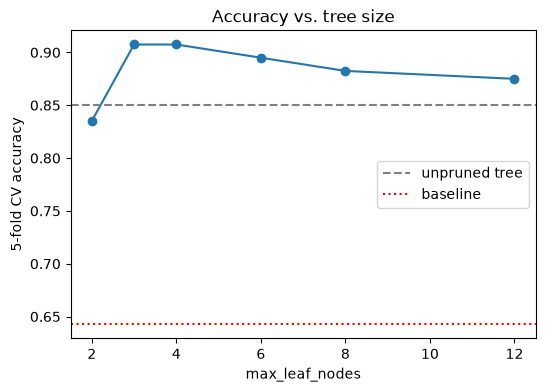

In [3]:
baseline_acc = 1 - ya.mean()
print(f"baseline ('nobody purchases') accuracy: {baseline_acc:.4f}")

tree_unpruned = DecisionTreeClassifier(random_state=7034)
acc_unpruned = cv_acc(tree_unpruned)
print(f"unpruned tree CV accuracy:              {acc_unpruned:.4f}")

leaf_grid = [2, 3, 4, 6, 8, 12]
leaf_acc = {}
for m in leaf_grid:
    t = DecisionTreeClassifier(max_leaf_nodes=m, random_state=7034)
    leaf_acc[m] = cv_acc(t)

leaf_acc_s = pd.Series(leaf_acc, name='CV accuracy')
leaf_acc_s.index.name = 'max_leaf_nodes'
print(leaf_acc_s.round(4))

best_m = max(leaf_acc, key=lambda k: (leaf_acc[k], -k))  # ties -> smaller size
print(f"\nCV-preferred size: max_leaf_nodes={best_m}, accuracy={leaf_acc[best_m]:.4f}")

# why 3 and 4 leaves tie: compare their out-of-fold predictions person by person
from sklearn.model_selection import cross_val_predict
from sklearn.tree import export_text
p3 = cross_val_predict(DecisionTreeClassifier(max_leaf_nodes=3, random_state=7034), Xa, ya, cv=cv5)
p4 = cross_val_predict(DecisionTreeClassifier(max_leaf_nodes=4, random_state=7034), Xa, ya, cv=cv5)
print(f"3- and 4-leaf trees give identical out-of-fold predictions for all {len(ya)} people: {np.array_equal(p3, p4)}")
print(export_text(DecisionTreeClassifier(max_leaf_nodes=4, random_state=7034).fit(Xa, ya),
                  feature_names=list(Xa.columns), show_weights=True))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(leaf_acc_s.index, leaf_acc_s.values, marker='o')
ax.axhline(acc_unpruned, color='gray', ls='--', label='unpruned tree')
ax.axhline(baseline_acc, color='red', ls=':', label='baseline')
ax.set_xlabel('max_leaf_nodes'); ax.set_ylabel('5-fold CV accuracy')
ax.legend(); ax.set_title('Accuracy vs. tree size')
plt.show()


**Answer:** The "nobody purchases" rule is right for everyone who did not buy, **64.25%** of the 400 people. That is the floor every model has to beat.

The unpruned tree scores **85.00%**: well above the floor, but below every pruned size from 3 to 12 leaves.

Sweeping `max_leaf_nodes`: 2 leaves 83.50%, **3 leaves 90.75%, 4 leaves 90.75%**, 6 leaves 89.50%, 8 leaves 88.25%, 12 leaves 87.50%. Cross-validation prefers **3 leaves**: it ties with 4 and the rule says take the smaller. The tie is exact because the fourth leaf never changes a prediction. The 3- and 4-leaf trees give the same out-of-fold prediction for every one of the 400 people (checked in the cell above). On the full data, for example, the fourth leaf splits the over-42.5 group again at age 46.5, and both halves still predict "buys".

Either side of the optimum: with 2 leaves the tree can use only one of the two things that matter (age or salary), so it underfits. Beyond 4 leaves, accuracy falls across the rest of the grid (6 leaves: 89.5%, 8: 88.25%, 12: 87.5%), and the unpruned tree is lowest at 85.0%. The extra splits fit patterns specific to each training fold that the held-out fold does not share. This is the usual complexity trade-off (an inverted U in accuracy), the reason Lecture 8 gives for pruning a tree and choosing its size out of sample.

**1.2.** Plot the tree you chose in 1.1 (`plot_tree` with `feature_names=Xa.columns`), and then **say what it does in one or two English sentences** — the kind you could put in front of someone with no statistics.

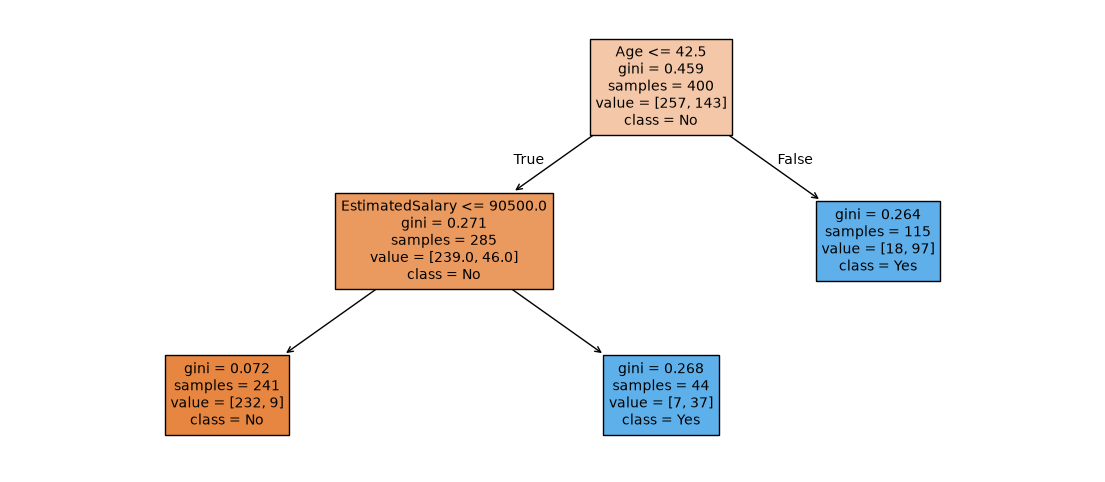

In-sample feature importance (MDI) of the chosen tree:
Gender             0.000
Age                0.613
EstimatedSalary    0.387
dtype: float64


In [4]:
best_tree = DecisionTreeClassifier(max_leaf_nodes=best_m, random_state=7034).fit(Xa, ya)

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(best_tree, feature_names=Xa.columns, class_names=['No', 'Yes'], filled=True, ax=ax, fontsize=10)
plt.show()

print("In-sample feature importance (MDI) of the chosen tree:")
print(pd.Series(best_tree.feature_importances_, index=Xa.columns).round(3))


**Answer:** **Anyone older than about 42 is predicted to buy, whatever they earn; among people 42 or younger, only those earning more than about \$90,500 are predicted to buy.** Gender is never used.

**1.3.** Fit a random forest (300 trees) and a gradient boosted model (100 rounds), both with `random_state=7034`, and report their 5-fold accuracies.

Do they beat the tree from 1.1? Report what you find **whichever way it comes out**, and explain in two or three sentences why that might be, given the size and shape of this dataset.

In [5]:
rf = RandomForestClassifier(n_estimators=300, random_state=7034)
gb = GradientBoostingClassifier(n_estimators=100, random_state=7034)

acc_rf = cv_acc(rf)
acc_gb = cv_acc(gb)

comparison = pd.Series({
    f'Single tree (max_leaf_nodes={best_m})': leaf_acc[best_m],
    'Random Forest (300 trees)': acc_rf,
    'Gradient Boosting (100 rounds)': acc_gb,
}, name='CV accuracy')
print(comparison.round(4))

# the same five folds, model by model: how big is the gap relative to fold-to-fold noise?
fold_acc = pd.DataFrame({
    'tree': cross_val_score(DecisionTreeClassifier(max_leaf_nodes=best_m, random_state=7034), Xa, ya, cv=cv5),
    'RF':   cross_val_score(rf, Xa, ya, cv=cv5),
    'GBRT': cross_val_score(gb, Xa, ya, cv=cv5),
}, index=[f'fold {i}' for i in range(1, 6)])
print(); print(fold_acc.round(4))
for e in ['RF', 'GBRT']:
    d = fold_acc['tree'] - fold_acc[e]
    print(f"tree minus {e}: mean {d.mean():+.4f}, sd across folds {d.std():.4f}, "
          f"paired t = {d.mean() / (d.std() / np.sqrt(len(d))):.2f}, tree loses in {(d < 0).sum()} of 5 folds")

# does boosting lose because it has too few rounds (Lecture 8's California case) or too many?
print("\nGBRT accuracy by number of rounds (defaults otherwise):",
      {n: round(cv_acc(GradientBoostingClassifier(n_estimators=n, random_state=7034)), 4) for n in [10, 50, 100, 300, 1000]})


Single tree (max_leaf_nodes=3)    0.9075
Random Forest (300 trees)         0.8875
Gradient Boosting (100 rounds)    0.8900
Name: CV accuracy, dtype: float64



          tree      RF    GBRT
fold 1  0.8500  0.8625  0.8625
fold 2  0.9000  0.9125  0.9000
fold 3  0.9125  0.8875  0.9125
fold 4  0.9250  0.8500  0.8375
fold 5  0.9500  0.9250  0.9375
tree minus RF: mean +0.0200, sd across folds 0.0360, paired t = 1.24, tree loses in 2 of 5 folds
tree minus GBRT: mean +0.0175, sd across folds 0.0401, paired t = 0.98, tree loses in 1 of 5 folds



GBRT accuracy by number of rounds (defaults otherwise): {10: np.float64(0.9075), 50: np.float64(0.8925), 100: np.float64(0.89), 300: np.float64(0.875), 1000: np.float64(0.8575)}


**Answer:** Neither ensemble beats the pruned tree. RF scores **88.75%** and GBRT **89.00%**, against **90.75%** for the 3-leaf tree. The gaps are 2.0 and 1.75 percentage points, i.e. 8 and 7 of the 400 people. That is small next to fold-to-fold noise: the tree loses to RF in two of the five folds and to GBRT in one, and the paired t-statistics are only 1.24 and 0.98 (fold-based tests if anything overstate significance, because the training folds overlap). So the honest reading is "the ensembles do not improve on the tree", not "the tree is significantly better".

Why: the signal is two thresholds on two variables (age, then salary), which a 3-leaf tree already captures with little variance, so on 400 people and three features there is little variance left for an ensemble to remove. The forest averages *deep, unpruned* trees (Lecture 8: "each tree is grown deep and not pruned — the averaging does the regularizing"), which still carve up the region where buyers and non-buyers overlap, and with three columns its column subsampling has little room to decorrelate them. Boosting with default settings (100 rounds of depth-3 trees) is, if anything, too flexible for a two-threshold rule on 400 people: its accuracy falls as rounds are added (10 rounds 90.75%, 100 rounds 89.00%, 1,000 rounds 85.75%), the opposite of Lecture 8's California case, where 100 rounds were too few.

**1.4.** Split the data 70/30 (`random_state=7034`, `stratify=ya`), fit a 300-tree forest on the training set, and compute two importance rankings: `feature_importances_` (mean decrease in impurity, computed **in sample**) and `permutation_importance` on the **held-out** 30%.

Put them side by side. Do the two rankings agree on which variable matters most? Where they disagree, explain why — and say which of the two you would show to someone making a decision.

In [6]:
Xtr, Xte, ytr, yte = train_test_split(Xa, ya, test_size=0.3, random_state=7034, stratify=ya)

rf_split = RandomForestClassifier(n_estimators=300, random_state=7034).fit(Xtr, ytr)

mdi = pd.Series(rf_split.feature_importances_, index=Xa.columns, name='MDI (in-sample)')
perm = permutation_importance(rf_split, Xte, yte, n_repeats=30, random_state=7034)
perm_s = pd.Series(perm.importances_mean, index=Xa.columns, name='Permutation (held-out)')
perm_sd = pd.Series(perm.importances_std, index=Xa.columns, name='Permutation sd')

importance_table = pd.concat([mdi, perm_s, perm_sd], axis=1).sort_values('Permutation (held-out)', ascending=False)
print(importance_table.round(4))
print("\ndistinct values per feature, full data:", Xa.nunique().to_dict(), " training split:", Xtr.nunique().to_dict())


                 MDI (in-sample)  Permutation (held-out)  Permutation sd
Age                       0.4699                  0.2567          0.0410
EstimatedSalary           0.5191                  0.1725          0.0298
Gender                    0.0111                  0.0192          0.0114

distinct values per feature, full data: {'Gender': 2, 'Age': 43, 'EstimatedSalary': 117}  training split: {'Gender': 2, 'Age': 42, 'EstimatedSalary': 108}


**Answer:** The two rankings **disagree on which variable matters most.** MDI ranks `EstimatedSalary` slightly ahead of `Age` (0.52 vs. 0.47). Permutation importance on the held-out 30% ranks `Age` first by a clear margin (0.26 vs. 0.17 of accuracy lost when the column is shuffled). Both agree that `Gender` is close to irrelevant.

This is the disagreement Lecture 8 warns about. MDI is computed **in sample**, on the rows each tree was grown on, and "MDI rewards a column for merely offering many places to split" (Lecture 8). The forest's trees are grown deep, so they keep splitting on `EstimatedSalary` (117 distinct values against 43 for `Age` in the full data; 108 and 42 in the training split) to chase small impurity gains in the training rows, and every such split adds to its MDI whether or not it helps on new people. Permutation importance asks how much held-out accuracy falls when a column is scrambled, so splits that only fit training noise earn nothing. I would show a decision-maker the **permutation ranking**. It answers the question they are asking ("how much worse would predictions on new customers be without this variable?"), not a question about how the tree-growing algorithm searched.

**1.5** (Open-Ended) Each row here is a *person*, and the rows are unrelated to each other. Suppose instead each row were a *month* of one stock's data, and you were predicting whether next month's return is positive.

Cross-validation with `shuffle=True` — which you used throughout this problem — would then be **wrong**. Explain precisely what goes wrong, what you would do instead, and which way the error would push your reported accuracy.

**Answer:** With `shuffle=True` each fold is a random set of months. For every test month, the months right before and after it, and months from years later, sit in the training folds. That is harmless for unrelated people. It is not harmless for one stock over time: monthly returns themselves are at most weakly autocorrelated, but their environment is persistent. Volatility, valuation and trailing-return predictors move slowly, and returns drift through slow regimes. A test month's neighbours therefore have nearly identical predictors and share its regime. A flexible model can learn the regime from those neighbours, interpolating from both sides, and "predict" the test month with information that did not exist in real time. It also learns any relationship that only appears later in the sample before the months it is scored on.

**What to do instead:** use time-ordered evaluation, in which every validation month comes strictly after every training month. That means an expanding or rolling window refit as time moves forward (Lecture 5, "Cross-Validation for Time-Series Data"), with any tuning (tree size here) done inside the training window the same way, and a final test block that follows everything used for fitting and tuning. Leave a gap of a few months between training and validation when predictors use overlapping windows, so they cannot straddle the boundary.

**Direction of the error:** shuffled CV makes the reported accuracy **too high**. Validation error looks better than it will be in real time (AI Coding Guide §4(a): the out-of-sample number "will look wonderful and mean nothing"). The bias grows with how persistent the predictors and regimes are, and would be small only if the months really were independent. It can also mis-select the model. In Lecture 5's macro example, choosing the lasso penalty with random 5-fold instead of an expanding window kept 23 variables instead of 15 and cost 0.036 of true out-of-sample $R^2$ (−0.0405 against −0.0046).

---
# Problem 2: Training on Your Own Output (20 points)

A risk desk estimates the daily volatility of its portfolio from a library of past daily returns
and reports the one-day 1% Value-at-Risk. Under a fitted normal distribution $N(0, \hat\sigma^2)$
the 1% quantile is $-2.326\,\hat\sigma$, so the desk reports $\text{VaR} = 2.326\,\hat\sigma$: under
this model, estimating VaR *is* estimating $\hat\sigma$. In 2016 the desk decided that the library
should be refreshed every night so that it always reflects the newest model. Its pipeline manual:

> *Every night the pipeline **(1)** fits $\hat\sigma^2$ to the library with the usual unbiased sample
> variance, $\hat\sigma^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar x)^2$, and sets the mean of the
> fitted normal to zero; **(2)** draws 500 fresh scenarios from $N(0, \hat\sigma^2)$; **(3)** replaces
> the library with tonight's 500 scenarios, so the library keeps its size, because the newest model is the best model and
> yesterday's data came from a worse one; and **(4)** reports $\text{VaR} = 2.326\,\hat\sigma$.*

On the first night the library held 500 real daily returns. The pipeline then ran every night for
ten years, 2,500 refits in all, and the reported VaR fell from 2.8% of NAV to 0.24%, while the
volatility of the desk's markets had not changed. The desk was praised for de-risking. The Chief Risk Officer, who does not
believe in free lunches, wants to know what happened.

**Rules.** Work in units of the true volatility: $\sigma = 1$, so the *correct* VaR is $2.326$ on
every night and nothing about the market changes. Set `SEED` to the last four digits of your student ID; your numbers will differ from your classmates', and that is the point. A "desk" is one run of the
pipeline; every desk starts on night 1 from a library whose sample variance is exactly 1, and when a
part needs the real days themselves, take them to be 500 draws from $N(0, 1)$. Every number you
report must come from a cell in this notebook.


In [7]:
from scipy.stats import norm, kurtosis
import time

SEED   = 0             # <-- replace with the last four digits of your own student ID before comparing;
                        #     left at 0 here so this reference solution is reproducible.
N_SCEN = 500
NIGHTS = 2500
Z01    = norm.ppf(0.99)
print(f"correct VaR, every night, in units of sigma: {Z01:.3f}")


correct VaR, every night, in units of sigma: 2.326


**2.1.** (2 points) **Commit before you compute.** Answer in the markdown cell below *before*
writing any code. The estimator in step (1) is unbiased, so each night's estimate is, on average,
equal to the previous night's. Does that mean the reported VaR should stay near 2.326 for ten
years? Say what you expect to see on night 2,500 and why, in two or three sentences. No marks depend
on being right; **2.3** asks you to reconcile your answer with what you find.


**Answer (written before running any code):** Unbiasedness gives $E[\hat\sigma^2_{2500}] = 1$ by induction, so on average across many desks I expect the VaR to stay near 2.326. For a single desk, each night adds sampling noise (with $n=500$ the standard deviation of $\hat\sigma^2$ around its target is about $\sqrt{2/499}\approx 6\%$), and over 2,500 nights these errors compound rather than cancel. So I expect one desk's night-2,500 VaR to be noticeably away from 2.326, without a view on which direction.

**2.2.** (6 points) **One desk, then a thousand.** Simulate one desk for 2,500 nights exactly as
the manual describes: fit $\hat\sigma^2$ with `var(ddof=1)`, draw 500 scenarios from
$N(0, \hat\sigma^2)$, replace the library. Plot $\log\hat\sigma^2$ against the night and report
$\hat\sigma^2$ and the reported VaR on night 2,500.

Then run a thousand desks (a loop over nights that draws a $1000 \times 500$ matrix each night takes
seconds). For night 2,500 report the mean, median, 5th and 95th percentiles and maximum of
$\hat\sigma^2$, and the fraction of desks reporting a VaR below one-tenth of the truth. Where does
your one desk sit in that distribution? Is the story's fall from 2.8% to 0.24% typical?


night-1 sample variance (ddof=1): 1.0
night 2500: sigma_hat^2 = 0.00443,  reported VaR = 0.1548  (true VaR = 2.326)


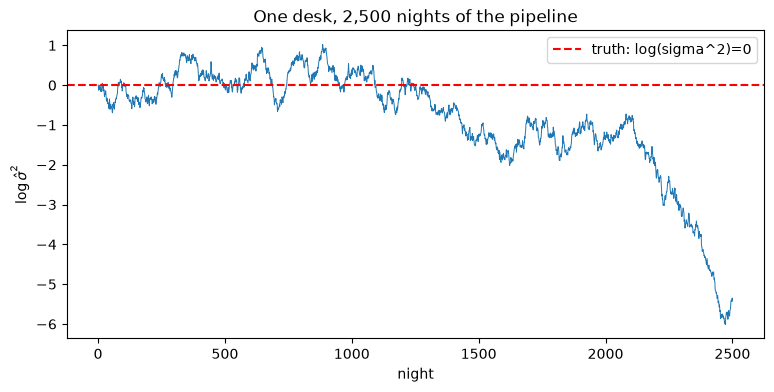

In [8]:
rng = np.random.default_rng(SEED)

# --- one desk ---
library = rng.standard_normal(N_SCEN)
library = library / library.std(ddof=1)          # night-1 library has sample variance exactly 1
print("night-1 sample variance (ddof=1):", round(library.var(ddof=1), 6))

sigma2_path = np.empty(NIGHTS)
lib = library.copy()
for t in range(NIGHTS):
    s2 = lib.var(ddof=1)
    sigma2_path[t] = s2
    lib = rng.normal(0, np.sqrt(s2), size=N_SCEN)

print(f"night 2500: sigma_hat^2 = {sigma2_path[-1]:.5f},  reported VaR = {Z01*np.sqrt(sigma2_path[-1]):.4f}  (true VaR = {Z01:.3f})")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, NIGHTS+1), np.log(sigma2_path), lw=0.7)
ax.axhline(0, color='red', ls='--', label='truth: log(sigma^2)=0')
ax.set_xlabel('night'); ax.set_ylabel(r'$\log\hat\sigma^2$')
ax.set_title('One desk, 2,500 nights of the pipeline')
ax.legend()
plt.show()


In [9]:
# --- a thousand desks ---
M = 1000
rng_m = np.random.default_rng(SEED)
lib0 = rng_m.standard_normal((M, N_SCEN))
lib0 = lib0 / lib0.std(axis=1, ddof=1, keepdims=True)

libs = lib0.copy()
t0 = time.time()
for t in range(NIGHTS):
    sigma2_m = libs.var(axis=1, ddof=1)
    z = rng_m.standard_normal((M, N_SCEN))
    libs = z * np.sqrt(sigma2_m)[:, None]
print(f"simulated {M} desks x {NIGHTS} nights in {time.time()-t0:.1f}s")

final_sigma2 = sigma2_m
summary_2_2 = pd.Series({
    'mean':   final_sigma2.mean(),
    'median': np.median(final_sigma2),
    '5th pct': np.percentile(final_sigma2, 5),
    '95th pct': np.percentile(final_sigma2, 95),
    'max':    final_sigma2.max(),
})
print(summary_2_2.round(5))
print(f"mean / median = {final_sigma2.mean() / np.median(final_sigma2):.0f}")

frac_tiny_var = (Z01*np.sqrt(final_sigma2) < 0.1*Z01).mean()
print(f"\nfraction of 1,000 desks reporting VaR < 1/10 of truth: {frac_tiny_var:.3f}")

one_desk_final = sigma2_path[-1]
pct_rank = (final_sigma2 < one_desk_final).mean()
print(f"one desk's night-2500 sigma_hat^2 = {one_desk_final:.5f} sits at the {100*pct_rank:.1f}th percentile of the 1,000-desk distribution")
print(f"one desk's VaR fell {1/np.sqrt(one_desk_final):.1f}x, from {Z01:.3f} to {Z01*np.sqrt(one_desk_final):.3f}")

# the story: VaR 2.8% -> 0.24% of NAV with unchanged market volatility
story_sigma2 = (0.24 / 2.8) ** 2
print(f"story: VaR fell {2.8/0.24:.1f}x, i.e. sigma_hat^2 fell to {story_sigma2:.4f} of its start; "
      f"that sits at the {100*(final_sigma2 < story_sigma2).mean():.1f}th percentile of the 1,000 desks")


simulated 1000 desks x 2500 nights in 19.1s
mean         0.47574
median       0.00764
5th pct      0.00004
95th pct     1.28245
max         48.10267
dtype: float64
mean / median = 62

fraction of 1,000 desks reporting VaR < 1/10 of truth: 0.533
one desk's night-2500 sigma_hat^2 = 0.00443 sits at the 41.6th percentile of the 1,000-desk distribution
one desk's VaR fell 15.0x, from 2.326 to 0.155
story: VaR fell 11.7x, i.e. sigma_hat^2 fell to 0.0073 of its start; that sits at the 48.8th percentile of the 1,000 desks


**Answer:** One desk: on night 2,500, $\hat\sigma^2 = 0.00443$ and the reported VaR is **0.155** against a true 2.326, a **15.0x** fall with no change in the market. The plot shows $\log\hat\sigma^2$ wandering but trending down.

A thousand desks on night 2,500:

| statistic of $\hat\sigma^2$ | value |
|---|---|
| mean | 0.476 |
| median | 0.00764 |
| 5th percentile | 0.00004 |
| 95th percentile | 1.282 |
| maximum | 48.1 |

**53.3%** of the desks report a VaR below one-tenth of the truth. My one desk sits at the **41.6th** percentile, just below the median, so it is a typical desk, not an unlucky one.

Is the story typical? The story's VaR fell from 2.8% to 0.24% of NAV, an 11.7x fall, so its $\hat\sigma^2$ ended at $(0.24/2.8)^2 = 0.0073$ of where it started. That sits at the **48.8th** percentile of the thousand desks, almost exactly the median. **The story is the typical outcome of this pipeline.** The desk was not de-risking; its model of risk collapsed, as most desks running this pipeline do. The distribution is also extremely skewed: the mean (0.476) is 62 times the median, and one desk ended at 48.1, so a few desks blow up instead of collapsing.

**2.3.** (6 points) **Unbiased every night, wrong in the end.** Verify in a cell that
$E[\hat\sigma^2_{t+1} \mid \hat\sigma^2_t] = \hat\sigma^2_t$: start many desks at the same
$\hat\sigma^2_t$, take one step of the pipeline, and average. So the mathematically expected value
of $\hat\sigma^2$ on night 2,500 is exactly 1. Then measure the *average nightly change in
$\log\hat\sigma^2$* for $n = 50$, $500$ and $5{,}000$ scenarios per night (a few hundred desks and a
few hundred nights are enough) and propose the formula relating it to $n$; it is simple. Plot the
histogram of $\log\hat\sigma^2$ across your thousand desks on night 2,500.

In one paragraph, reconcile three numbers that are all correct: the expectation is exactly 1, your
median is far below 1, and your thousand-desk mean is neither (what share of the sum of your
thousand estimates is held by the ten largest?). Why does "unbiased at every step" not protect a
pipeline that trains on its own output?


In [10]:
# --- verify unbiasedness of one step, at two different starting levels ---
rng_v = np.random.default_rng(SEED)
M_v = 5000
for sigma2_start in [1.0, 4.0]:
    draws = rng_v.normal(0, np.sqrt(sigma2_start), size=(M_v, N_SCEN))
    sigma2_next = draws.var(axis=1, ddof=1)
    se = sigma2_next.std(ddof=1) / np.sqrt(M_v)
    print(f"start sigma^2={sigma2_start}:  E[sigma^2_(t+1)] over {M_v} desks = {sigma2_next.mean():.5f} "
          f"(Monte Carlo s.e. {se:.5f}, z = {(sigma2_next.mean() - sigma2_start) / se:+.2f})")


start sigma^2=1.0:  E[sigma^2_(t+1)] over 5000 desks = 0.99942 (Monte Carlo s.e. 0.00089, z = -0.65)


start sigma^2=4.0:  E[sigma^2_(t+1)] over 5000 desks = 4.00067 (Monte Carlo s.e. 0.00360, z = +0.19)


In [11]:
# --- average nightly change in log(sigma^2), for a few hundred desks/nights, at n=50,500,5000 ---
from scipy.special import digamma
def avg_log_change(n, n_desks=500, n_nights=300, seed=SEED):
    rng_n = np.random.default_rng(seed)
    sigma2 = np.ones(n_desks)
    changes = np.empty((n_nights, n_desks))
    for t in range(n_nights):
        z = rng_n.standard_normal((n_desks, n))
        new_sigma2 = z.var(axis=1, ddof=1) * sigma2
        changes[t] = np.log(new_sigma2 / sigma2)
        sigma2 = new_sigma2
    return changes.mean(), changes.std() / np.sqrt(changes.size)

drift_table = pd.DataFrame({'n': [50, 500, 5000]})
est = [avg_log_change(n) for n in drift_table['n']]
drift_table['simulated avg nightly change in log(sigma^2)'] = [e[0] for e in est]
drift_table['std. error'] = [e[1] for e in est]
drift_table['-1/n'] = -1 / drift_table['n']
# exact: (n-1) sigma2_next / sigma2 ~ chi2(n-1)  =>  E[log ratio] = log 2 + digamma((n-1)/2) - log(n-1)
drift_table['exact E[log change]'] = np.log(2) + digamma((drift_table['n'] - 1) / 2) - np.log(drift_table['n'] - 1)
print(drift_table.round(6).to_string(index=False))


   n  simulated avg nightly change in log(sigma^2)  std. error    -1/n  exact E[log change]
  50                                     -0.021314    0.000528 -0.0200            -0.020547
 500                                     -0.002036    0.000164 -0.0020            -0.002005
5000                                     -0.000138    0.000052 -0.0002            -0.000200


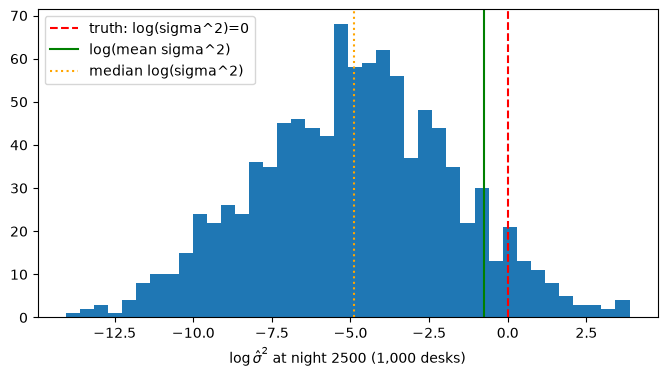

share of the SUM of all 1,000 desks' sigma^2 held by the 10 largest: 56.1%
log sigma^2 at night 2500:  theory N(-5.01, 3.17^2)   simulated mean -4.90, sd 3.14
implied median exp(mu) = 0.0067 (simulated 0.0076);  implied mean exp(mu+s^2/2) = 1.007
half of E[sigma^2] comes from desks with sigma^2 > exp(mu+s^2) = 152; probability 0.00077, i.e. 0.77 such desks expected among 1,000 (largest simulated desk: 48.1)


across 2,000 simulated 1,000-desk cohorts: median sample mean 0.671, share of cohorts with sample mean below 1: 0.76, P(a cohort has no desk above 152) = 0.46


In [12]:
# --- histogram of log(sigma^2) across the 1,000 desks at night 2500 (reusing final_sigma2 from 2.2) ---
from scipy.special import polygamma
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log(final_sigma2), bins=40)
ax.axvline(0, color='red', ls='--', label='truth: log(sigma^2)=0')
ax.axvline(np.log(final_sigma2.mean()), color='green', ls='-', label='log(mean sigma^2)')
ax.axvline(np.median(np.log(final_sigma2)), color='orange', ls=':', label='median log(sigma^2)')
ax.set_xlabel(r'$\log\hat\sigma^2$ at night 2500 (1,000 desks)')
ax.legend()
plt.show()

share_top10 = np.sort(final_sigma2)[-10:].sum() / final_sigma2.sum()
print(f"share of the SUM of all 1,000 desks' sigma^2 held by the 10 largest: {share_top10:.1%}")

# theory: log sigma^2 is a random walk with iid steps log(chi2_{n-1}/(n-1)); night 2500 = 2,499 steps from 1
k, steps = N_SCEN - 1, NIGHTS - 1
mu = steps * (np.log(2) + digamma(k / 2) - np.log(k))
s = np.sqrt(steps * polygamma(1, k / 2))
print(f"log sigma^2 at night 2500:  theory N({mu:.2f}, {s:.2f}^2)   simulated mean {np.log(final_sigma2).mean():.2f}, sd {np.log(final_sigma2).std():.2f}")
print(f"implied median exp(mu) = {np.exp(mu):.4f} (simulated {np.median(final_sigma2):.4f});  implied mean exp(mu+s^2/2) = {np.exp(mu + s**2/2):.3f}")
print(f"half of E[sigma^2] comes from desks with sigma^2 > exp(mu+s^2) = {np.exp(mu + s**2):.0f}; "
      f"probability {norm.sf(s):.5f}, i.e. {1000*norm.sf(s):.2f} such desks expected among 1,000 "
      f"(largest simulated desk: {final_sigma2.max():.1f})")

# how would OTHER 1,000-desk samples look?  Draw 2,000 cohorts from the (very accurate) lognormal approximation
rng_c = np.random.default_rng(SEED)
cohort_means = np.exp(mu + s * rng_c.standard_normal((2000, 1000))).mean(axis=1)
print(f"across 2,000 simulated 1,000-desk cohorts: median sample mean {np.median(cohort_means):.3f}, "
      f"share of cohorts with sample mean below 1: {(cohort_means < 1).mean():.2f}, "
      f"P(a cohort has no desk above {np.exp(mu + s**2):.0f}) = {(1 - norm.sf(s)) ** 1000:.2f}")


**Answer:** The one-step check confirms unbiasedness within Monte Carlo error. Starting 5,000 desks at $\hat\sigma^2_t=1$ (or 4), one step of the pipeline averages 0.9994 (or 4.0007), 0.65 and 0.19 standard errors from the starting value. The property itself is exact: $\hat\sigma^2_{t+1} = \hat\sigma^2_t\cdot\chi^2_{n-1}/(n-1)$ with $E[\chi^2_{n-1}/(n-1)]=1$.

The average nightly change in $\log\hat\sigma^2$ is **$-1/n$**: −0.0213 at $n=50$, −0.00204 at $n=500$ and −0.00014 at $n=5{,}000$, against −0.02, −0.002 and −0.0002. The exact value is $\log 2+\psi(\tfrac{n-1}2)-\log(n-1)\approx-\tfrac1{n-1}$ (−0.02055, −0.00201, −0.00020), and every simulated value is within 1.5 standard errors of it.

**Reconciliation.** All three numbers are correct.

- **The expectation is exactly 1.** This follows from the tower property (each night multiplies $\hat\sigma^2$ by a mean-one factor). The lognormal approximation reproduces it: $e^{\mu+s^2/2} = 1.007$.
- **The median is far below 1.** Jensen's inequality ($E[\log X] < \log E[X] = 0$) gives each of the 2,499 steps of $\log\hat\sigma^2$ a mean of about $-1/500$. On night 2,500, $\log\hat\sigma^2$ is therefore close to $N(-5.01, 3.17^2)$; the simulated desks give $-4.90$ and $3.14$. The typical desk sits at $e^{\mu}\approx 0.0067$ (simulated median 0.0076).
- **The thousand-desk mean (0.476) is neither.** Half the expectation is carried by desks above $e^{\mu+s^2}\approx 152$, and each desk gets there with probability 0.08%. So whether 1,000 desks contain even one such desk is close to a coin flip (46% chance of none). Ours contain none: the largest reached 48.1. The sample mean is therefore carried by a handful of desks (the ten largest hold **56.1%** of the sum). Across 2,000 simulated cohorts its median is 0.67, and it is below 1 in 76% of them.

"Unbiased at every step" does not protect a pipeline that trains on its own output. Unbiasedness only fixes the average across many parallel desks. Each desk multiplies its variance by a fresh mean-one factor every night and never sees real data again. A process like that heads to zero along almost every path, and its expectation is held at one only by ever rarer, ever larger blow-ups. My 2.1 prior was right only about the mathematical expectation. Even the 1,000-desk average is not near 1, and the single desk did not wander without direction: it drifted down, at about $1/n$ per night.

**2.4.** (6 points) **What synthetic data can and cannot carry.** Two experiments.

(a) Keep the 500 real days in the library permanently, and add each night's 500 scenarios to them
instead of replacing them, so the library holds 1,000 returns, half real and half synthetic. Report the median and the 5th and 95th percentiles of $\hat\sigma^2$ on
night 2,500 across a thousand desks.

(b) Seed the library with real returns instead. `dj30.csv` is a daily panel of Dow stocks, one row
per stock per date, and the daily market return `MrkRet` is repeated on every row for that date;
reduce it to one value per date (for example `dj.groupby('date').MrkRet.first()`), which gives 1,511
trading days for 2016–2021 including March 2020. Report the sample volatility and the excess
kurtosis of the real returns. Then compare two things *on night 1, before the pipeline has drawn a
single scenario from its own output*: the empirical 1% VaR (the first percentile of the real
returns, sign flipped) against the VaR the pipeline reports, and the excess kurtosis of the real
returns against that of the 500 night-1 scenarios.

Then answer in one paragraph. What does a synthetic sample contain that the real sample did not,
and what does it lack? Which of the two experiments shows a *loss of information* and which shows
an *accumulation of noise*? What does this imply for any pipeline, a risk model, a return forecast
or a language model, that is retrained on data produced by its own previous version, and what is the
only thing that stops it?


In [13]:
# --- (a) permanent real anchor: 500 real days kept forever + tonight's 500 scenarios ---
M2 = 1000
rng_a = np.random.default_rng(SEED)
real_part = rng_a.standard_normal((M2, N_SCEN))
real_part = real_part / real_part.std(axis=1, ddof=1, keepdims=True)   # each desk's real days: sample variance exactly 1

s2_a = real_part.var(axis=1, ddof=1)        # night 1: the library is the 500 real days only
for t in range(1, NIGHTS):                 # nights 2..2500: library = 500 real + last night's 500 scenarios
    synth_part = rng_a.standard_normal((M2, N_SCEN)) * np.sqrt(s2_a)[:, None]
    s2_a = np.concatenate([real_part, synth_part], axis=1).var(axis=1, ddof=1)

summary_2_4a = pd.Series({
    'median': np.median(s2_a),
    '5th pct': np.percentile(s2_a, 5),
    '95th pct': np.percentile(s2_a, 95),
})
print("Experiment (a) — permanent real anchor, sigma^2 at night 2500 across 1,000 desks:")
print(summary_2_4a.round(4))
print(f"cross-desk sd of sigma^2: {s2_a.std():.4f}   (a library of only the 500 real days would report exactly 1.0000 every night)")


Experiment (a) — permanent real anchor, sigma^2 at night 2500 across 1,000 desks:
median      1.0003
5th pct     0.9441
95th pct    1.0586
dtype: float64
cross-desk sd of sigma^2: 0.0351   (a library of only the 500 real days would report exactly 1.0000 every night)


In [14]:
# --- (b) real dj30 market returns ---
dj = pd.read_csv(_DATA_DIR + 'dj30.csv')
mkt = dj.groupby('date').MrkRet.first()
mkt.index = pd.to_datetime(mkt.index.astype(str), format='%Y%m%d')   # dates are stored as YYYYMMDD integers
print("trading days:", len(mkt), mkt.index.min().date(), "-", mkt.index.max().date())

real_vol = mkt.std(ddof=1)
real_kurt = kurtosis(mkt.values, fisher=True)
empirical_VaR = -np.percentile(mkt.values, 1)
print(f"real sample vol: {real_vol:.5f}   real excess kurtosis: {real_kurt:.2f}")
covid = (mkt.index >= '2020-02-15') & (mkt.index <= '2020-04-30')
print(f"excess kurtosis without 15 Feb - 30 Apr 2020 ({covid.sum()} days dropped): {kurtosis(mkt[~covid].values, fisher=True):.2f}")
print(f"empirical 1% VaR (1st percentile, sign-flipped): {empirical_VaR:.4f}")

sigma2_night1 = mkt.var(ddof=1)
pipeline_VaR = Z01 * np.sqrt(sigma2_night1)
print(f"pipeline's night-1 (Gaussian, fitted) VaR:        {pipeline_VaR:.4f}")

rng_b = np.random.default_rng(SEED)
scen1 = rng_b.normal(0, np.sqrt(sigma2_night1), size=N_SCEN)
scen_kurt = kurtosis(scen1, fisher=True)
print(f"\nexcess kurtosis, 500 night-1 SYNTHETIC scenarios: {scen_kurt:.2f}   (vs. real: {real_kurt:.2f}; "
      f"sampling s.d. of excess kurtosis for 500 normal draws ~ sqrt(24/500) = {np.sqrt(24 / N_SCEN):.2f})")


trading days: 1511 2016-01-04 - 2021-12-31
real sample vol: 0.01195   real excess kurtosis: 24.07
excess kurtosis without 15 Feb - 30 Apr 2020 (52 days dropped): 5.28
empirical 1% VaR (1st percentile, sign-flipped): 0.0333
pipeline's night-1 (Gaussian, fitted) VaR:        0.0278

excess kurtosis, 500 night-1 SYNTHETIC scenarios: 0.46   (vs. real: 24.07; sampling s.d. of excess kurtosis for 500 normal draws ~ sqrt(24/500) = 0.22)


**Answer:** (a) With the 500 real days kept permanently, nothing collapses or explodes. On night 2,500 the median $\hat\sigma^2$ across 1,000 desks is **1.0003**, with 5th and 95th percentiles **0.944** and **1.059**. The real half contributes a variance of exactly 1 every night and makes up half of every fit. Tonight's synthetic error therefore enters tomorrow's estimate at half weight and dies out geometrically instead of compounding, and $\hat\sigma^2$ can never fall below $499/999 \approx 0.5$. The spread is still not zero, though. The 500 real days alone would report exactly 1.000 on every desk, every night. Essentially all of the 0.944–1.059 band (s.d. 0.035) is sampling noise from the synthetic half, and none of it is information about the market.

(b) The DJ30 market return over 2016–2021 (1,511 days) has a daily sample volatility of **1.195%** and an excess kurtosis of **24.07**. The fat tails come largely from the COVID crash: dropping 15 February–30 April 2020 brings the kurtosis down to about 5. On night 1, before the pipeline has drawn a single scenario from its own output, it already understates risk. The empirical 1% VaR (first percentile, sign flipped) is **3.33%**, while the fitted-normal VaR the pipeline reports is **2.78%**, the "2.8% of NAV" in the story. The 500 night-1 scenarios, drawn from $N(0,\hat\sigma^2)$, have an excess kurtosis of **0.46**. The scenarios are normal by construction, so 0.46 is just a roughly two-standard-deviation sampling fluctuation (s.d. ≈ 0.22 for 500 draws) around a normal's 0, and negligible next to the 24.07 of the data they were fitted to.

**What a synthetic sample contains and lacks.** It contains what the real sample did not: the model's assumptions (normal, thin-tailed, zero mean, independent days) and fresh noise, i.e. the estimation error in $\hat\sigma$ plus the randomness of the draws. It lacks everything the model did not capture: the fat tails, the true 1% quantile, the crash days and volatility clustering. **Experiment (b) shows the loss of information**: the tails are gone after one generation, before any feedback loop has run. **Experiment (a) shows the accumulation of noise**: even with a permanent real anchor, recycling synthetic draws adds variation to the estimate that has nothing to do with the market (a 0.944–1.059 band where the real data alone give exactly 1). Without the anchor, as in 2.2–2.3, that noise compounds without limit into the collapse. **For any pipeline retrained on its own previous output** (a risk model, a return forecast, a language model trained on its own text), each generation passes on only what the previous model could represent, plus fresh sampling error that the next generation treats as data. What the model missed, typically the tails and the rare events, is lost for good. The noise feeds back, and although the average across many runs can look fine, the typical run degenerates. **The only thing that stops it is real data from outside the loop.** A permanent share of genuine observations stops the drift (experiment a), but only real data, and new real data over time, can put back what the model never captured (experiment b).

---
# Problem 3: Research Project — Cross-country asset return prediction (60 points)

This is an open-ended research project rather than a problem set. You are given a research panel of monthly asset returns across several countries and asset classes, with asset-level characteristics and macroeconomic data, and a question. How you answer it — which features you build, which models you fit, how you evaluate them — is your design, and the write-up must defend it. There is no answer key. A negative result, honestly established, earns full credit; an unexplained positive one does not.

**The question.** The empirical asset-pricing literature finds that a small set of asset-level characteristics — variables that describe each asset's own recent behaviour, pricing and risk, and that differ across assets at a point in time — predict returns across many markets and asset classes, and systematic funds trade on exactly these cross-sectional signals. The panel you are given carries five such characteristics per asset, with their names hidden, together with global and country-level macro variables. What a desk that trades across countries and asset classes wants to know is:

1. How much of next month's excess return is forecastable from lagged characteristics?
2. Does macroeconomic information — global or country-level — add anything to the characteristics?
3. Does a forecast-based portfolio beat the simple rules (equal weight, risk parity, time-series momentum) out of sample, after costs?

Any method is allowed: OLS, ridge, lasso, PCR, KNN, trees, random forests, boosting, neural networks, or anything else you want to try; static, expanding-window or rolling-window estimation; cross-validation or information criteria for tuning. The choice is yours; the discipline of the evaluation is what is graded.


## Data

All files are in `_DATA_DIR`. Dates are month-ends, January 2000 to December 2024. Returns are monthly **excess** returns in decimals. Asset, asset-class, country and variable names are anonymized.

| file | grain | columns |
|---|---|---|
| `asset_panel.csv` | asset × month (50 × 300) | `date, asset_id, asset_class, country, excess_return, x1 ... x5` |
| `asset_returns_wide.csv` | month × asset | the same returns, one column per asset |
| `asset_info.csv` | asset | `asset_class` (A, B, C, D) and `country` of each asset |
| `macro_global.csv` | month | `x6 ... x9`, global variables |
| `macro_country.csv` | country × month, 12 countries | `x10 ... x16`, curated country-level variables |
| `macro_country_extended.csv` | country × month, 12 countries | `x17 ... x164`, a wide, uncurated set of further country-level variables that overlaps the curated file (a few of its columns duplicate curated series exactly; find them before you concatenate the two files). Treat as exploratory material of uneven quality |

**Universe.** 50 assets in four asset classes — A (26 assets), B (8), C (9) and D (7) — across 12 countries. Assets in classes B, C and D each belong to one country. **Assets in class A have no natural country**; in the files they are assigned `country_7` by convention (a country that also has one class-C and one class-D asset). If you use country-level macro for class A, the convention gives them country 7's variables, which is one defensible choice among several (see step 2 of the workflow); in a widened-panel design you can give them whatever cross-country information you find sensible.

**Variables.** `x1` to `x5` are cross-sectional asset characteristics: each is computed for every asset every month from that asset's own prices and fundamentals, so at any date it varies across assets and can be used to rank them (one of the five is a risk measure). `x6` to `x164` are macroeconomic and financial-condition variables: rates, inflation, activity, external balances, credit, valuation, uncertainty and risk ratings, and some pre-computed transforms of them. Working out what a variable does — from its persistence, its scale, its cross-sectional behaviour and its relation to returns — is part of the project.

**Read this before modelling.**
- **Lag conventions.** `x2` and `x5` are *already* lagged one month: use them as they are to predict `excess_return` in the same row. `x1`, `x3`, `x4` and **every macro variable** are stored *contemporaneously*: shift them by one month within asset (or country) before using them as predictors. Getting this wrong silently introduces look-ahead. Macro data is also released with a delay; a one-month lag is the minimum, and you may argue for more.
- **Missing values.** The asset panel and the global file have no gaps, but a few leading months of `x2`, `x3` and `x5` in 2000–2002 were filled with the first observed value for a handful of assets; returns were never filled. In the curated country file, `x11` stops being updated before the end of the sample for three countries. In the extended file, seven columns have gaps. If you want to use a series with gaps, you have to deal with them yourself (see step 2 of the workflow).
- **You are free to bring in more data.** If you think other macro series, other asset characteristics, or other information would help the prediction, find it, document its source and its release timing, and treat it as part of your feature engineering. Anything you add is subject to the same lag rules as the data we provide.
- **Scales differ enormously by class.** Monthly return volatility ranges from under 1% to above 17% across assets, and its typical level differs systematically across the four classes. Think about this before pooling assets in one regression or one equal-weighted portfolio.


## Two rules that apply throughout

1. **Benchmarks before models.** Before you fit anything, write down the simple rules your model must beat and compute their out-of-sample performance. For return forecasts the benchmark is the trailing mean (or zero). For portfolios it is equal weight, risk parity ($w_i \propto 1/\hat\sigma_i$, with $\hat\sigma_i$ a trailing volatility computed from past returns) and time-series momentum ($w_i \propto \mathrm{sign}(\text{trailing 12-month return}_i)/\hat\sigma_i$), all with unit gross exposure and monthly rebalancing. All three can be built from `excess_return` alone.
2. **Time-ordered evaluation.** Fix the out-of-sample window and the initial training block in advance, before you fit anything, and say why you chose them. Every predictor must be known at the end of month $t-1$; every scaler, penalty and hyper-parameter is chosen on training data only; the trailing-mean benchmark for month $t$ is the mean of returns through month $t-1$ only, updated each month (the expanding-window harness of HW5 Problem 1.1, where the $R^2$ benchmark is the mean of the data seen so far).


## A suggested workflow

You do not have to follow this order, but a complete project touches each step.

**1. Know your data.** Cumulative excess returns by asset class; a table of annualized mean, volatility, Sharpe ratio and worst month per asset; the correlation matrix ordered by class (how strong is the block structure, and what does it imply for pooling?); rolling 12-month Sharpe by class (how persistent is performance?); the distribution, scale and persistence of each characteristic within each class, and a first look at its predictive content (average next-month return of assets sorted into terciles on it each month). Form a hypothesis about what each of `x1` to `x5` measures; you will need it to interpret your results.

**2. Feature engineering.** This is where most of the design lives.
- Apply the lag rule. Standardize characteristics cross-sectionally within month (across all assets or within class; z-score or rank) and say why.
- **If you use a macro series with missing values, deal with them first and write down what you did.** Diagnose the pattern for each series and country: does it stop early, or have holes in the middle? Then choose a treatment and justify that it uses *only information available at the time*. Forward-filling the last observed value and dropping the series are legitimate; filling backward, interpolating across a gap, or imputing with a full-sample mean all use the future. One trap worth your attention: a series that stops updating during a regime change, where carrying a stale value forward is not a small error. Check whether the series can be rebuilt, exactly or approximately, from other complete columns in either file, and report how close the rebuild is.
- **Add your own data if you have a hypothesis for it.** More macro series, other characteristics, anything you can source and date properly. Say where it came from, when each value became known, and lag it accordingly.
- Standardize global macro with *trailing* information only (a rolling z-score, for instance), never with the full sample.
- Map country macro to assets through `country`. Classes B, C and D each have their own country, so the mapping is direct; a *differential* against a base country (country 7 is the natural base) is often more informative than a level. Class A has no natural country. The files assign it country 7 by convention, and using country 7's macro for class A is one defensible choice; a cross-country average, cross-country dispersion, or no country macro at all are others. Say which you use and why.
- Consider cross-sectional macro transforms: the rank of a country's value across the 12 countries, its deviation from the cross-country mean, or a widened panel in which each asset sees its own country's macro *and* the cross-country average or every country's value. In the widened panel, class A can be given any cross-country information you find sensible rather than one country's.
- Consider interactions between characteristics and macro states, class dummies, and the extended file if you have a hypothesis for it.
- Choose the target. We recommend the **vol-scaled** excess return $y_{i,t} = r_{i,t}/\hat\sigma_{i,t-1}$ with $\hat\sigma$ a trailing volatility; explain why, and how you turn forecasts back into positions.
- End with one table listing every predictor and the count.

**3. Models and evaluation schemes.** Fit whatever models you find promising — OLS, ridge, lasso, random forests, boosted trees, neural networks, or any other method — and evaluate them under one or more schemes: static (fit once on the initial training block), expanding window (refit periodically on all data to date, the expanding-window scheme of Lecture 5 that you implemented in HW5 Problem 1), rolling window (refit on a fixed-length trailing window). Report $R^2_{OOS}$ against the trailing mean and against zero, model × scheme, and by asset class for the models you care about. Questions worth answering along the way: which scheme wins and why; which predictors carry the signal and whether that is stable across windows; whether macro adds anything once you refit without it; whether a **placebo** (every macro series circularly shifted by 36 months, real data at the wrong time) does about as well as the real macro (a persistent series stays partly correlated with a shifted copy of itself, so try more than one shift); whether per-class models beat the pooled one.

**4. From forecasts to portfolios.** Form portfolios from your forecasts in whatever way you find sensible (positions proportional to the forecast scaled by volatility, the sign of the forecast, long the top and short the bottom of a sort, or your own rule). State clearly how the portfolio is formed and rebalanced, and compare its performance with the benchmarks — Sharpe ratio at a minimum, and whatever else helps the reader judge it (return, volatility, drawdown, turnover, performance net of transaction costs, cumulative-return plots, sub-periods). Where you find outperformance, ask how much of it is exposure to the benchmark rules and how much is timing.


In [15]:
import seaborn as sns
import statsmodels.api as sm
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

panel   = pd.read_csv(_DATA_DIR + 'asset_panel.csv', parse_dates=['date'])
info    = pd.read_csv(_DATA_DIR + 'asset_info.csv', index_col=0)
rw      = pd.read_csv(_DATA_DIR + 'asset_returns_wide.csv', parse_dates=['date']).set_index('date')
mac_g   = pd.read_csv(_DATA_DIR + 'macro_global.csv', parse_dates=['date'])
mac_c   = pd.read_csv(_DATA_DIR + 'macro_country.csv', parse_dates=['date'])
mac_x   = pd.read_csv(_DATA_DIR + 'macro_country_extended.csv', parse_dates=['date'])

panel = panel.sort_values(['asset_id', 'date']).reset_index(drop=True)
cls_map = info['asset_class']
print(panel.shape, panel.date.min().date(), panel.date.max().date())
print("assets per class:", cls_map.value_counts().sort_index().to_dict())
print("extended file:", mac_x.shape[1] - 2, "variable columns")
panel.head()


(15000, 10) 2000-01-31 2024-12-31
assets per class: {'A': 26, 'B': 8, 'C': 9, 'D': 7}
extended file: 148 variable columns


,date,asset_id,asset_class,country,excess_return,x1,x2,x3,x4,x5
0,2000-01-31,asset_1,A,country_7,0.035385,0.044852,0.970233,-0.109145,0.158469,0.086743
1,2000-02-29,asset_1,A,country_7,0.116676,0.073761,0.974766,-0.109145,0.133949,0.085443
2,2000-03-31,asset_1,A,country_7,0.040920,0.089627,0.922260,-0.109145,0.188675,0.086244
3,2000-04-30,asset_1,A,country_7,-0.008399,0.074356,1.055247,-0.109145,0.206628,0.085047
4,2000-05-31,asset_1,A,country_7,-0.086259,0.067134,0.788085,-0.109145,0.227556,0.083820


## 1. Know your data

In [16]:
# ---- backfilled leading values (prompt: "a few leading months of x2, x3 and x5 in 2000-2002 were filled
# with the first observed value for a handful of assets").  A fill copies a LATER value into earlier months,
# i.e. it is look-ahead.  Detect each asset's leading run of identical values and blank the copies.
def leading_fill_mask(s):
    v = s.values
    k = 1
    while k < len(v) and v[k] == v[0]:
        k += 1
    m = np.zeros(len(v), dtype=bool)
    m[:k - 1] = True                    # positions 0..k-2 copy the first genuine observation at k-1
    return pd.Series(m, index=s.index)

backfill_report = {}
for c in ['x2', 'x3', 'x5']:
    mask = panel.groupby('asset_id', group_keys=False)[c].apply(leading_fill_mask)
    assert panel.loc[mask, 'date'].max() <= pd.Timestamp('2002-12-31')
    backfill_report[c] = panel.loc[mask].groupby('asset_id').size().to_dict()
    panel.loc[mask, c] = np.nan
print("backfilled leading values set to NaN (asset: months blanked):", backfill_report)
# (done here, before any exploration, so no statistic below uses the copied values; see Section 2)


backfilled leading values set to NaN (asset: months blanked): {'x2': {'asset_22': 1, 'asset_3': 9}, 'x3': {'asset_1': 30, 'asset_2': 30, 'asset_21': 31, 'asset_26': 30, 'asset_5': 30}, 'x5': {'asset_3': 15}}


In [17]:
stats = pd.DataFrame({
    'ann_mean': rw.mean() * 12,
    'ann_vol':  rw.std() * np.sqrt(12),
    'sharpe':   rw.mean() / rw.std() * np.sqrt(12),
    'worst_month': rw.min(),
}).join(info)

print("Per-asset annualized statistics (2000-2024), sorted by class:")
print(stats.sort_values(['asset_class', 'ann_vol']).round(3).to_string())
print()
print("Class averages of the per-asset statistics:")
print(stats.groupby('asset_class')[['ann_mean', 'ann_vol', 'sharpe', 'worst_month']].mean().round(3))


Per-asset annualized statistics (2000-2024), sorted by class:
          ann_mean  ann_vol  sharpe  worst_month asset_class     country
asset_19     0.023    0.147   0.158       -0.211           A   country_7
asset_6      0.079    0.161   0.490       -0.185           A   country_7
asset_5     -0.001    0.202  -0.007       -0.169           A   country_7
asset_39     0.062    0.243   0.254       -0.318           A   country_7
asset_32     0.100    0.248   0.401       -0.234           A   country_7
asset_28     0.093    0.252   0.371       -0.253           A   country_7
asset_43     0.089    0.256   0.347       -0.365           A   country_7
asset_26     0.049    0.269   0.182       -0.341           A   country_7
asset_36     0.002    0.274   0.006       -0.228           A   country_7
asset_48     0.076    0.278   0.272       -0.245           A   country_7
asset_2      0.086    0.280   0.308       -0.275           A   country_7
asset_13    -0.004    0.291  -0.012       -0.241           A  

Volatility differs enormously by class. Class A averages 30% a year (15% to 60% across its 26 assets), class C 17%, class B 10% and class D 6%, i.e. monthly volatility from under 1% (asset_16) to over 17% (asset_47). Class D has the highest average Sharpe ratio (0.46) and class B the lowest (−0.03), and class A's average worst month is −29%. Pooling raw returns would let class A dominate any squared-error loss and any equal-weighted portfolio. That is the motivation for the vol-scaled target in Section 2 and for the risk-parity benchmark in Section 7.

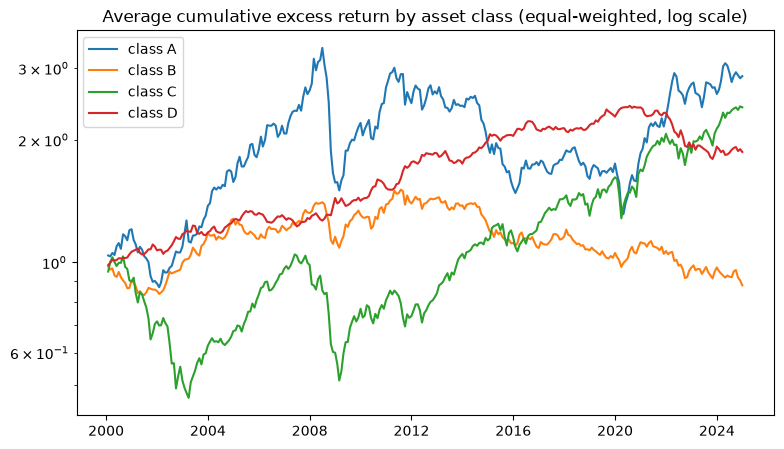

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
for cls in sorted(cls_map.unique()):
    assets_in_cls = cls_map[cls_map == cls].index
    avg_cum = (1 + rw[assets_in_cls]).cumprod().mean(axis=1)
    ax.plot(avg_cum.index, avg_cum.values, label=f'class {cls}')
ax.set_yscale('log')
ax.legend(); ax.set_title('Average cumulative excess return by asset class (equal-weighted, log scale)')
plt.show()


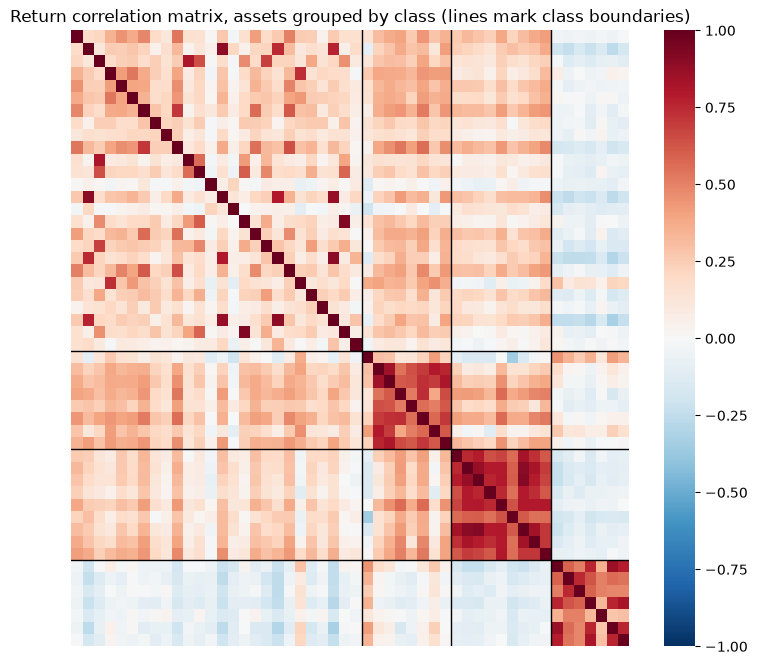

average pairwise correlation within (diagonal) and across (off-diagonal) classes:
       A      B      C      D
A  0.211  0.240  0.176 -0.080
B  0.240  0.550  0.230  0.053
C  0.176  0.230  0.725 -0.104
D -0.080  0.053 -0.104  0.580


In [19]:
# correlation matrix, assets ordered by class, to see the block structure
order = info.sort_values('asset_class').index
corr = rw[order].corr()
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, ax=ax)
class_bounds = info.loc[order, 'asset_class'].reset_index(drop=True)
for b in class_bounds[class_bounds != class_bounds.shift()].index[1:]:
    ax.axhline(b, color='black', lw=1); ax.axvline(b, color='black', lw=1)
ax.set_title('Return correlation matrix, assets grouped by class (lines mark class boundaries)')
plt.show()

classes = sorted(cls_map.unique())
block = pd.DataFrame(index=classes, columns=classes, dtype=float)
for a in classes:
    for b in classes:
        sub = corr.loc[cls_map[cls_map == a].index, cls_map[cls_map == b].index].values
        block.loc[a, b] = sub[np.triu_indices_from(sub, k=1)].mean() if a == b else sub.mean()
print("average pairwise correlation within (diagonal) and across (off-diagonal) classes:")
print(block.round(3))


The block structure is clear but uneven. Within-class correlation is high for C (0.73), D (0.58) and B (0.55), and **lowest for class A (0.21)**, even though all 26 class-A assets sit in `country_7`. Class-A assets are about as correlated with class B (0.24) as with each other. Class D is slightly *negatively* correlated with A (−0.08) and C (−0.10), so it behaves like a hedge. For pooling this means that each of B, C and D moves largely as one block: little independent cross-sectional variation within the class, and a lot of class-level common movement. Class A offers much more independent cross-sectional variation.

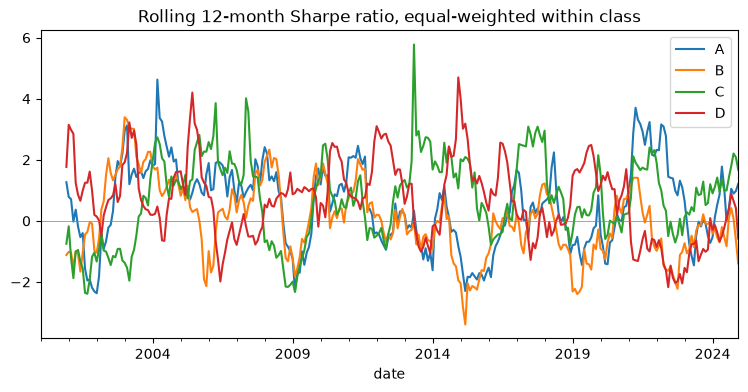

correlation of each class's calendar-year Sharpe with the previous year's:
{'A': -0.063, 'B': 0.136, 'C': -0.008, 'D': -0.104}


In [20]:
# rolling 12-month Sharpe by class, and how persistent performance is from one year to the next
cls_ret = pd.DataFrame({c: rw[cls_map[cls_map == c].index].mean(axis=1) for c in classes})
roll_sharpe = cls_ret.rolling(12).mean() / cls_ret.rolling(12).std() * np.sqrt(12)
fig, ax = plt.subplots(figsize=(9, 4))
roll_sharpe.plot(ax=ax)
ax.axhline(0, color='gray', lw=0.5)
ax.set_title('Rolling 12-month Sharpe ratio, equal-weighted within class')
plt.show()

annual_sharpe = cls_ret.groupby(cls_ret.index.year).apply(lambda g: g.mean() / g.std() * np.sqrt(12))
print("correlation of each class's calendar-year Sharpe with the previous year's:")
print(annual_sharpe.apply(lambda s: s.autocorr(1)).round(3).to_dict())


Performance is not persistent. The rolling 12-month Sharpe ratios swing between strongly positive and strongly negative for every class, and the correlation of a class's calendar-year Sharpe ratio with the previous year's is between −0.10 and 0.14. Past class-level performance says little about next year's.

In [21]:
# characteristics: scale and persistence, pooled and WITHIN each class
char_cols_raw = ['x1', 'x2', 'x3', 'x4', 'x5']
print("pooled distribution:")
print(panel[char_cols_raw].describe().T[['mean', 'std', 'min', 'max']].round(3))
print("\ndistribution by class (all months):")
print(panel.groupby('asset_class')[char_cols_raw].agg(['mean', 'std', 'min', 'median', 'max']).T.round(3).to_string())
print("\ncross-sectional std within month, averaged over months, by class:")
print(panel.groupby(['date', 'asset_class'])[char_cols_raw].std().groupby('asset_class').mean().round(4))
print("\naverage within-asset AR(1) persistence, by class:")
ar1 = panel.groupby('asset_id')[char_cols_raw].apply(lambda g: g.apply(lambda s: s.autocorr(1)))
print(ar1.join(info['asset_class']).groupby('asset_class').mean().round(3))


pooled distribution:
     mean    std    min    max
x1  0.253  0.847 -2.383  6.572
x2  0.050  0.280 -0.842  2.672
x3 -0.256  0.748 -9.496  0.963
x4  0.004  0.778 -4.712  7.961
x5  0.059  0.036  0.004  0.273

distribution by class (all months):
asset_class      A      B      C      D
x1 mean     -0.003 -0.000  0.012  1.802
   std       0.024  0.002  0.054  1.524
   min      -0.141 -0.006 -0.244 -2.383
   median   -0.003 -0.000  0.006  1.676
   max       0.148  0.005  0.409  6.572
x2 mean      0.069 -0.000  0.057  0.026
   std       0.363  0.106  0.190  0.072
   min      -0.842 -0.305 -0.562 -0.262
   median    0.006 -0.006  0.077  0.026
   max       2.672  0.446  0.683  0.244
x3 mean     -0.259  0.038 -0.701 -0.008
   std       0.956  0.209  0.347  0.012
   min      -9.496 -0.695 -1.713 -0.060
   median   -0.018  0.055 -0.668 -0.008
   max       0.963  0.579  0.282  0.038
x4 mean      0.000 -0.017  0.038 -0.000
   std       0.054  1.304  1.357  0.004
   min      -0.400 -4.712 -4.360 -0.

                x1     x2     x3     x4     x5
asset_class                                   
A            0.525  0.909  0.969  0.425  0.987
B            0.950  0.915  0.973  0.974  0.988
C            0.329  0.927  0.958  0.955  0.988
D            0.981  0.925  0.975  0.953  0.987


In [22]:
# what are x1..x5?  compare with return-based quantities each asset's own history can produce
g_ret = panel.groupby('asset_id')['excess_return']
cand = pd.DataFrame({
    'trailing 12m return, t-12..t-1': g_ret.transform(lambda s: (1 + s).shift(1).rolling(12).apply(np.prod, raw=True) - 1),
    'trailing 60m return, t-60..t-1': g_ret.transform(lambda s: (1 + s).shift(1).rolling(60).apply(np.prod, raw=True) - 1),
    'trailing 12m vol, t-12..t-1':    g_ret.transform(lambda s: s.shift(1).rolling(12).std()),
    'trailing 36m vol, t-36..t-1':    g_ret.transform(lambda s: s.shift(1).rolling(36).std()),
})
print("correlation of each characteristic with candidate definitions (pooled):")
print(pd.concat([panel[char_cols_raw], cand], axis=1).corr().loc[char_cols_raw, cand.columns].round(3).to_string())
x2_gap = (panel['x2'] - cand['trailing 12m return, t-12..t-1']).abs().dropna()
print(f"\n|x2 - trailing 12m compounded return|: median {x2_gap.median():.2e}; share below 1e-5: {(x2_gap < 1e-5).mean():.3f}; "
      f"rows differing by more than 0.01: {(x2_gap > 0.01).sum()} of {len(x2_gap)} (max {x2_gap.max():.2f})")


correlation of each characteristic with candidate definitions (pooled):
    trailing 12m return, t-12..t-1  trailing 60m return, t-60..t-1  trailing 12m vol, t-12..t-1  trailing 36m vol, t-36..t-1
x1                           0.010                           0.013                       -0.298                       -0.335
x2                           0.993                           0.469                        0.046                        0.102
x3                          -0.457                          -0.943                       -0.098                       -0.127
x4                          -0.084                          -0.004                        0.030                        0.033
x5                           0.096                           0.098                        0.876                        1.000

|x2 - trailing 12m compounded return|: median 6.99e-07; share below 1e-5: 0.996; rows differing by more than 0.01: 45 of 14400 (max 2.29)


In [23]:
# first look at predictive content: sort into terciles on the characteristic KNOWN AT t-1,
# then average the NEXT-month (month t) excess return.  x2 and x5 are stored pre-lagged; x1, x3, x4 are shifted.
known_at_tm1 = {'x1': panel.groupby('asset_id')['x1'].shift(1), 'x2': panel['x2'],
                'x3': panel.groupby('asset_id')['x3'].shift(1), 'x4': panel.groupby('asset_id')['x4'].shift(1),
                'x5': panel['x5']}

def tercile_sort(values, within_class):
    d = panel[['date', 'asset_class', 'excess_return']].assign(c=values).dropna()
    keys = ['date', 'asset_class'] if within_class else ['date']
    d['t'] = d.groupby(keys)['c'].transform(lambda s: pd.qcut(s.rank(method='first'), 3, labels=[1, 2, 3]))
    return d.groupby('t', observed=True)['excess_return'].mean() * 12

_y = panel['excess_return'] / panel.groupby('asset_id')['excess_return'].transform(lambda s: s.shift(1).rolling(12).std())
def within_class_spread_y(values):
    """T3 - T1 of next-month vol-scaled return within each class-month, averaged over classes, t over months."""
    d = panel[['date', 'asset_class']].assign(c=values, y=_y).dropna()
    d['t'] = d.groupby(['date', 'asset_class'])['c'].transform(lambda s: pd.qcut(s.rank(method='first'), 3, labels=[1, 2, 3]))
    m = d.groupby(['date', 'asset_class', 't'], observed=True)['y'].mean().unstack()
    spread = (m[3] - m[1]).groupby(level='date').mean()
    return pd.Series({'T3-T1 (y units)': spread.mean(), 't': spread.mean() / spread.std() * np.sqrt(len(spread))})
print("within-class T3 - T1 on the vol-scaled target y (the modelling target), averaged across classes:")
print(pd.DataFrame({c: within_class_spread_y(v) for c, v in known_at_tm1.items()}).T.round(3)); print()

print("for contrast, the look-ahead version (same-month x1, x4 against same-month returns), pooled T3 - T1, % a year:",
      {c: round(100 * (lambda t: t.iloc[-1] - t.iloc[0])(tercile_sort(panel[c], False)), 2) for c in ['x1', 'x4']})
print()
for within in [False, True]:
    tab = pd.DataFrame({c: tercile_sort(v, within) for c, v in known_at_tm1.items()}).T
    tab.columns = ['T1 (low)', 'T2', 'T3 (high)']
    tab['T3 - T1'] = tab['T3 (high)'] - tab['T1 (low)']
    print(('WITHIN-CLASS' if within else 'POOLED') + " terciles, next-month excess return, annualized %:")
    print((tab * 100).round(2)); print()


within-class T3 - T1 on the vol-scaled target y (the modelling target), averaged across classes:


    T3-T1 (y units)      t
x1            0.024  1.109
x2           -0.004 -0.171
x3            0.046  2.497
x4            0.029  1.465
x5           -0.050 -2.503



for contrast, the look-ahead version (same-month x1, x4 against same-month returns), pooled T3 - T1, % a year: {'x1': np.float64(11.32), 'x4': np.float64(9.33)}



POOLED terciles, next-month excess return, annualized %:
    T1 (low)    T2  T3 (high)  T3 - T1
x1      4.39  3.59       4.93     0.54
x2      2.95  1.96       7.89     4.94
x3      4.84  4.37       4.13    -0.70
x4      3.47  4.19       5.29     1.82
x5      1.69  6.03       5.41     3.72



WITHIN-CLASS terciles, next-month excess return, annualized %:
    T1 (low)    T2  T3 (high)  T3 - T1
x1      3.06  5.25       4.82     1.76
x2      3.57  3.97       5.40     1.83
x3      3.33  6.10       4.16     0.82
x4      3.33  4.37       5.32     1.99
x5      4.28  4.45       4.31     0.04



**What `x1`–`x5` are.** Three of the five can be pinned down from the data rather than guessed (cell above):
- **`x2` is 12-month momentum**: the trailing 12-month compounded return through $t-1$. It matches our own calculation to rounding on 99.6% of rows (median absolute difference $7\times10^{-7}$). The correlation is only 0.993 because 45 of 14,400 rows differ by more than 0.01, by up to 2.29, which looks like data errors. It is stored pre-lagged, as the prompt says. Pooled, it has the largest next-month tercile spread (+4.9% a year), but within class only +1.8%. Much of the pooled spread comes from high-return classes also having high trailing returns.
- **`x3` is minus the trailing 5-year return**, a long-term-reversal / value signal (correlation −0.94 with the compounded 60-month return). That explains its shape. It is capped near +1, because a return cannot fall below −100%, and has a long left tail (down to −9.5) from class-A assets that multiplied in value. Its spreads are small: −0.7% pooled, and +0.8% within class, where the pattern is not monotone.
- **`x5` is the risk measure**: trailing 36-month volatility (correlation 1.000). Pooled, its terciles are really class sorts, since the volatility level is set by the class. Within class its spread is essentially zero (+0.04% a year).
- **`x1` and `x4` are class-specific fundamentals.** Their scale and dynamics differ completely by class. `x1`'s cross-sectional standard deviation is 0.96 in class D and 0.001 in class B; it is slow-moving in B and D (AR(1) 0.95–0.98) and fast in A and C (0.53 and 0.33). `x4`'s is 0.58–0.65 in B and C and 0.002 in D; it is fast in A (0.43) and slow elsewhere (0.95–0.97). Neither is related to past returns (|correlation| ≤ 0.1), and `x1` is mildly negatively related to volatility (−0.3). They behave like carry or valuation ratios computed from each class's own fundamentals (yields, spreads). Within class both show modest positive spreads (+1.8% and +2.0% a year).

**On the modelling target**, i.e. vol-scaled next-month returns sorted within class, only two spreads are more than two standard errors from zero: `x3` (long-term reversal, T3 − T1 = +0.046, t = 2.50) and `x5` (low volatility, −0.050, t = −2.50). `x2`'s within-class spread is nil (t = −0.2).

**Consequences for the design.** (i) Because `x1` and `x4` live on class-specific scales, a z-score across all 50 assets mostly records which class an asset is in. We therefore standardize characteristics **within class**, and test the all-asset version in Section 4. (ii) Every within-class tercile spread is below 2% a year before costs. That is an early warning that the characteristics carry little signal here. (iii) Timing matters. An earlier version of this sort put *same-month* `x1`, `x3`, `x4` against same-month returns, which is look-ahead. It made `x1` and `x4` look strongly predictive (pooled spreads of 11.3% and 9.3% a year, printed above for contrast); correctly lagged, they are 0.5% and 1.8%. The backfilled values are also removed before any of these statistics are computed.

## 2. Feature engineering

**Lag rule.** `x2` and `x5` are stored already lagged. `x1`, `x3`, `x4` and every macro variable are contemporaneous and are shifted by one month within asset (or country). Macro is lagged the prompt's minimum of one month, **with one exception: `x10`**. It changes only in January and tracks the *same-year* average of the monthly series `x86` (correlation 0.998, against 0.84 for the previous year's). It is a calendar-year figure stamped on all twelve months. With a one-month lag, a forecast made in, say, June would use the average of months that have not happened yet (Lecture 5's "merge keyed on a period-end rather than a publication date"). We therefore lag `x10` 13 months, so year $Y$'s value is used from February of $Y+1$. We do not argue for longer publication lags on the other series, which is a limitation.

**Backfilled characteristics.** The prompt warns that a few leading months of `x2`, `x3` and `x5` were filled with the first observed value. A fill copies a *later* value into earlier months, so it is look-ahead. We detect each asset's leading run of identical values and blank the copies: `x3` for five assets (30–31 months each), `x2` for two (9 months and 1) and `x5` for one (15). All of them fall in 2000–2002, inside the training block.

**Missing macro values, diagnosed before treatment** (cells below):
- `x11` stops updating for three countries and has no interior holes: `country_12` after October 2020 (50 months), `country_9` after August 2021 (40) and `country_11` after March 2024 (9). The first two stop just before the 2021–23 inflation surge. That is the stale-value-in-a-regime-change trap the prompt warns about: forward-filling would freeze `country_12` at −0.18 and `country_9` at +0.37, while the rebuilt series (below) averages −7.4 and −2.5 in 2022. **It can be rebuilt.** The best single complete column correlates only 0.61 with it, but the difference `x86 − x12` correlates 0.988 (0.99 in `country_9`, 0.97 in `country_11`, 0.87 in `country_12`). It looks like a real rate: a nominal rate minus inflation. A time-honest test pretends `x11` stopped 36 months early and uses only data up to that pseudo-stop. We compare two rebuilds:
  - *chain-link:* the last observed value plus the subsequent change in `x86 − x12`. Its mean absolute error over those 36 months is 0.11 (`country_9`), 0.21 (`country_11`) and 0.03 (`country_12`).
  - *level:* `x86 − x12` plus a mean offset. Its error is 0.14, 0.19 and 0.40 respectively.

  Forward-filling has 1.22, 1.52 and 0.64. We use the chain-link rebuild, which is best by far for `country_12`, the case the prompt worries about. It uses only the country's own past `x11` and contemporaneous complete columns.
- Seven extended-file columns have gaps, all trailing (the series stop early): `x55, x82, x83, x113, x136, x163, x164`. They are forward-filled within country for completeness. The extended file is not used as a feature set (below), so this treatment does not affect any result.
- Ten extended columns are exact copies of six curated and all four global series (`x73`=`x10`, `x89`=`x12`, `x114`=`x13`, `x17`=`x14`, `x92`=`x15`, `x18`=`x16`, `x88`=`x6`, `x104`=`x7`, `x109`=`x8`, `x99`=`x9`), and `x160` is exactly `−x143`. All eleven are dropped. `x11` has no exact duplicate; its near-rebuild is above.

**Extended file.** Apart from `x86` in the rebuild of `x11`, the 148-column extended file is not used as features. We have no hypothesis for its uncurated series, and with a characteristic signal this weak, adding ~140 more columns would mostly add overfitting risk. This is a scope decision and a limitation.

**Country mapping.** Classes B, C and D use their own country's macro. Class A has no natural country and gets `country_7` by the files' convention. We keep that convention because it is the files' assignment and the simplest defensible choice, and the one that the exam's differential construction assumes. For the 26 class-A assets it means country macro is `country_7`'s levels only. Not tried: a cross-country average or dispersion for class A, cross-sectional ranks of each country's value, or a widened panel. We also compute each curated variable's **differential against `country_7`**. As a consequence, the seven differentials are identically zero for the 28 assets mapped to `country_7` (all 26 class-A assets plus one C and one D asset), so for more than half of the panel only the levels vary.

**Standardization.** Characteristics are z-scored **cross-sectionally within month and within asset class**, because `x1` and `x4` differ in scale by two to three orders of magnitude across classes (Section 1). An all-asset z-score is kept as a robustness check. Global macro gets a **trailing 60-month z-score** (minimum 24 months) of the lagged series, so month $t$ uses $x_{t-60},\dots,x_{t-1}$ only. Country macro enters as levels and differentials. The Ridge and Lasso fits standardize every predictor inside the pipeline, on training rows only, at every refit.

**Target.** The **vol-scaled excess return** $y_{i,t} = r_{i,t}/\hat\sigma_{i,t-1}$, with $\hat\sigma_{i,t-1}$ the 12-month realized volatility of returns through $t-1$ (so the first 12 months of every asset drop out). It puts a 30%-vol class-A asset and a 6%-vol class-D asset on the same footing in one pooled squared-error loss. A forecast $\hat y$ becomes a return forecast $\hat r = \hat y\,\hat\sigma_{i,t-1}$ for the $R^2$, and a position $w \propto \hat y/\hat\sigma_{i,t-1}$ in Section 7.

The table printed below lists every predictor and the count.

In [24]:
# ---- lag conventions ----
panel['x1_lag'] = panel.groupby('asset_id')['x1'].shift(1)
panel['x3_lag'] = panel.groupby('asset_id')['x3'].shift(1)
panel['x4_lag'] = panel.groupby('asset_id')['x4'].shift(1)
panel['x2_lag'] = panel['x2']   # already lagged
panel['x5_lag'] = panel['x5']   # already lagged


In [25]:
# ---- dedupe extended vs curated macro (exact duplicates), before concatenation ----
merged_check = mac_c.merge(mac_x, on=['country', 'date'], suffixes=('_c', '_x'))
curated_cols = ['x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16']
extended_cols = [c for c in mac_x.columns if c not in ('country', 'date')]

dupes = []
for cc in curated_cols:
    for xc in extended_cols:
        a, b = merged_check[cc], merged_check[xc]
        mask = a.notna() & b.notna()
        if mask.sum() >= 100 and np.allclose(a[mask], b[mask], atol=1e-6, rtol=1e-6):
            dupes.append((cc, xc))
g_merged = mac_x.merge(mac_g, on='date')
for gc in [c for c in mac_g.columns if c != 'date']:
    for xc in extended_cols:
        a, b = g_merged[gc], g_merged[xc]
        mask = a.notna() & b.notna()
        if mask.sum() >= 100 and np.allclose(a[mask], b[mask], atol=1e-6, rtol=1e-6):
            dupes.append((gc, xc))
print("curated/global column -> exact duplicate in the extended file:", dupes)

# within the extended file: exact copies or sign-flipped copies of another extended column
ext = mac_x[extended_cols]
cc = ext.corr().abs()
within = []
for i, a in enumerate(extended_cols):
    for b in extended_cols[i + 1:]:
        if cc.loc[a, b] > 0.9999:
            m = ext[a].notna() & ext[b].notna()
            for sgn, lab in [(1, 'copy'), (-1, 'sign flip')]:
                if np.allclose(ext.loc[m, a], sgn * ext.loc[m, b], atol=1e-6, rtol=1e-6):
                    within.append((a, b, lab))
print("pairs inside the extended file:", within)
mac_x_clean = mac_x.drop(columns=[xc for _, xc in dupes] + [b for _, b, _ in within])
assert 'x86' in mac_x_clean.columns   # needed below for the x11 rebuild


curated/global column -> exact duplicate in the extended file: [('x10', 'x73'), ('x12', 'x89'), ('x13', 'x114'), ('x14', 'x17'), ('x15', 'x92'), ('x16', 'x18'), ('x6', 'x88'), ('x7', 'x104'), ('x8', 'x109'), ('x9', 'x99')]


pairs inside the extended file: [('x143', 'x160', 'sign flip')]


In [26]:
# ---- diagnose every gap before treating it: which series, which countries, leading / interior / trailing ----
mac_c = mac_c.sort_values(['country', 'date']).reset_index(drop=True)

def gap_pattern(s):
    na = s.isna().values
    if not na.any():
        return None
    first, last = np.argmax(~na), len(na) - np.argmax(~na[::-1]) - 1
    return {'leading': int(na[:first].sum()), 'interior': int(na[first:last + 1].sum()),
            'trailing': int(na[last + 1:].sum())}

for c, grp in mac_c.groupby('country'):
    p = gap_pattern(grp['x11'])
    if p:
        print(f"x11, {c}: last observed {grp.loc[grp['x11'].notna(), 'date'].max().date()}, {p}")
print()
for c in mac_x_clean.columns[mac_x_clean.isna().any()]:
    pats = {ctry: gap_pattern(grp[c]) for ctry, grp in mac_x_clean.sort_values('date').groupby('country')}
    pats = {k: v for k, v in pats.items() if v}
    kinds = pd.DataFrame(pats).T.sum().to_dict()
    print(f"extended {c}: gaps in {len(pats)} countries, total months {kinds}")


x11, country_11: last observed 2024-03-31, {'leading': 0, 'interior': 0, 'trailing': 9}
x11, country_12: last observed 2020-10-31, {'leading': 0, 'interior': 0, 'trailing': 50}
x11, country_9: last observed 2021-08-31, {'leading': 0, 'interior': 0, 'trailing': 40}

extended x55: gaps in 3 countries, total months {'leading': 0, 'interior': 0, 'trailing': 6}
extended x82: gaps in 12 countries, total months {'leading': 0, 'interior': 0, 'trailing': 120}
extended x83: gaps in 12 countries, total months {'leading': 0, 'interior': 0, 'trailing': 120}
extended x113: gaps in 12 countries, total months {'leading': 0, 'interior': 0, 'trailing': 188}
extended x136: gaps in 8 countries, total months {'leading': 0, 'interior': 0, 'trailing': 53}
extended x163: gaps in 12 countries, total months {'leading': 0, 'interior': 0, 'trailing': 188}
extended x164: gaps in 12 countries, total months {'leading': 0, 'interior': 0, 'trailing': 188}


In [27]:
# ---- x11: can it be rebuilt from complete columns?  x86 (extended) minus x12 (curated) tracks it closely ----
xm = mac_c.merge(mac_x_clean[['country', 'date', 'x86']], on=['country', 'date'], how='left')
xm['x11_proxy'] = xm['x86'] - xm['x12']
obs = xm['x11'].notna()

cand_cols = [c for c in mac_x_clean.columns if c not in ('country', 'date') and mac_x_clean[c].notna().all()]
cand_cols += [c for c in curated_cols if c != 'x11']
both = mac_c.merge(mac_x_clean, on=['country', 'date'])
both = both[both['x11'].notna()]
single = both[cand_cols].corrwith(both['x11']).abs().sort_values(ascending=False)
print(f"best single complete column: {single.index[0]} (|corr| {single.iloc[0]:.3f});  "
      f"x86 - x12: corr {np.corrcoef(xm.loc[obs, 'x11'], xm.loc[obs, 'x11_proxy'])[0, 1]:.4f}")

# Time-honest check for the three affected countries: pretend x11 stopped 36 months before its real last value,
# estimate the rebuild's offset only on data up to that pseudo-stop, and compare with forward-filling.
rows = []
for c in ['country_9', 'country_11', 'country_12']:
    grp = xm[(xm.country == c) & obs].sort_values('date')
    fit, test = grp.iloc[:-36], grp.iloc[-36:]
    off = (fit['x11'] - fit['x11_proxy']).mean()
    chain = fit['x11'].iloc[-1] + (test['x11_proxy'] - fit['x11_proxy'].iloc[-1])
    rows.append({'country': c,
                 'corr (all observed months)': np.corrcoef(grp['x11'], grp['x11_proxy'])[0, 1],
                 'MAE forward-fill': (test['x11'] - fit['x11'].iloc[-1]).abs().mean(),
                 'MAE level rebuild (proxy + mean offset)': (test['x11'] - (test['x11_proxy'] + off)).abs().mean(),
                 'MAE chain-link rebuild (last value + change in proxy)': (test['x11'] - chain).abs().mean(),
                 'x11 std': grp['x11'].std()})
print("36-month pseudo-stop test (all inputs known at the time):")
print(pd.DataFrame(rows).set_index('country').round(3).to_string())

# Treatment (chain-link): after x11 stops, carry its last observed value forward PLUS the change in x86 - x12 since
# that month.  Only the country's own past x11 and the contemporaneous complete columns are used.
last_obs = xm[obs].groupby('country').tail(1).set_index('country')
offset = last_obs['x11'] - last_obs['x11_proxy']
_post = xm[xm.country.isin(['country_9', 'country_12']) & xm['x11'].isna()].copy()
_post['rebuilt'] = _post['x11_proxy'] + _post['country'].map(offset)   # = last x11 + change in proxy
_frozen = xm[obs].groupby('country')['x11'].last()
print("\nwhat forward-filling would carry vs the rebuilt series (annual means):")
print(_post.groupby(['country', _post.date.dt.year])['rebuilt'].mean().unstack().round(2).assign(
      **{'frozen value (ffill)': _frozen.reindex(['country_12', 'country_9']).round(2).values}))
xm['x11_rebuilt'] = xm['x11'].isna()
xm['x11'] = xm['x11'].fillna(xm['x11_proxy'] + xm['country'].map(offset))
mac_c = xm.drop(columns=['x86', 'x11_proxy'])
print("remaining NaNs in x11:", int(mac_c['x11'].isna().sum()), " months rebuilt:", int(mac_c['x11_rebuilt'].sum()))

# extended-file gaps are all trailing: forward-fill within country (uses only the past).  Note these columns
# are cleaned for completeness only -- the extended file is not used as a feature set (Section 2 text).
gappy_cols = mac_x_clean.columns[mac_x_clean.isna().any()].tolist()
mac_x_clean = mac_x_clean.sort_values(['country', 'date'])
mac_x_clean[gappy_cols] = mac_x_clean.groupby('country')[gappy_cols].ffill()
print("gappy extended columns forward-filled:", gappy_cols)


best single complete column: x86 (|corr| 0.608);  x86 - x12: corr 0.9882
36-month pseudo-stop test (all inputs known at the time):
            corr (all observed months)  MAE forward-fill  MAE level rebuild (proxy + mean offset)  MAE chain-link rebuild (last value + change in proxy)  x11 std
country                                                                                                                                                          
country_9                        0.992             1.218                                    0.137                                                  0.112    0.985
country_11                       0.972             1.521                                    0.191                                                  0.207    1.206
country_12                       0.871             0.638                                    0.397                                                  0.033    1.384

what forward-filling would carry vs the rebuilt series (an

In [28]:
# ---- lag ALL macro by 1 month (the minimum the prompt allows), within country / globally; x10 by 13 ----
mac_c = mac_c.sort_values(['country', 'date'])
mac_c_lagged = mac_c.copy()
mac_c_lagged[curated_cols] = mac_c.groupby('country')[curated_cols].shift(1)
# x10 is a calendar-year figure stamped on all 12 months of the year (it changes only in January, and it tracks the
# same-year average of the monthly series x86).  A 1-month lag would hand February-December forecasts the average of
# months that have not happened yet.  Lag it 13 months: year Y's value is used from February of Y+1.
_x10_change_months = mac_c.loc[mac_c.groupby('country')['x10'].diff().fillna(0) != 0, 'date'].dt.month.unique()
_ym = mac_x_clean.assign(year=mac_x_clean.date.dt.year).groupby(['country', 'year'])['x86'].mean()
_chk = mac_c.assign(year=mac_c.date.dt.year).join(_ym.rename('x86_same_year'), on=['country', 'year'])
_chk = _chk.join(_ym.rename('x86_prev_year').rename(index=lambda y: y + 1, level=1), on=['country', 'year'])
print("x10 changes only in calendar month(s):", sorted(_x10_change_months),
      "| corr with same-year mean of x86:", round(_chk[['x10', 'x86_same_year']].corr().iloc[0, 1], 3),
      "| with previous-year mean:", round(_chk[['x10', 'x86_prev_year']].corr().iloc[0, 1], 3))
mac_c_lagged['x10'] = mac_c.groupby('country')['x10'].shift(13)

mac_g_cols = [c for c in mac_g.columns if c != 'date']
mac_g_lagged = mac_g.sort_values('date').copy()
mac_g_lagged[mac_g_cols] = mac_g_lagged[mac_g_cols].shift(1)


x10 changes only in calendar month(s): [np.int32(1)] | corr with same-year mean of x86: 0.998 | with previous-year mean: 0.839


In [29]:
# ---- trailing (rolling) standardization of global macro: 60-month window, min 24 ----
# the value used at t is x_{t-1}; its mean/std use x_{t-60..t-1} only
mac_g_z = mac_g_lagged.copy()
for c in mac_g_cols:
    roll_mean = mac_g_z[c].rolling(60, min_periods=24).mean()
    roll_std = mac_g_z[c].rolling(60, min_periods=24).std()
    mac_g_z[c] = (mac_g_z[c] - roll_mean) / roll_std
mac_g_z = mac_g_z.rename(columns={c: c + '_z' for c in mac_g_cols})


In [30]:
# ---- country macro: curated levels + differential vs. base country (country_7) ----
base_country = 'country_7'
base_df = mac_c_lagged[mac_c_lagged.country == base_country][['date'] + curated_cols].rename(
    columns={c: c + '_base' for c in curated_cols})
mac_country_diff = mac_c_lagged[['country', 'date'] + curated_cols].merge(base_df, on='date', how='left')
for c in curated_cols:
    mac_country_diff[c + '_diff'] = mac_country_diff[c] - mac_country_diff[c + '_base']
country_feature_cols = curated_cols + [c + '_diff' for c in curated_cols]
mac_country_final = mac_country_diff[['country', 'date'] + country_feature_cols]

in_base = info[info.country == base_country]
print(f"assets mapped to {base_country}:", in_base.asset_class.value_counts().to_dict(),
      f"-> the 7 *_diff columns are identically 0 for these {len(in_base)} of {len(info)} assets")


assets mapped to country_7: {'A': 26, 'C': 1, 'D': 1} -> the 7 *_diff columns are identically 0 for these 28 of 50 assets


In [31]:
# ---- cross-sectional standardization of characteristics, within month ----
# primary: z-score WITHIN asset class (x1 and x4 differ in scale by orders of magnitude across classes);
# robustness: z-score across all 50 assets.
char_cols = ['x1_lag', 'x2_lag', 'x3_lag', 'x4_lag', 'x5_lag']
for c in char_cols:
    gc = panel.groupby(['date', 'asset_class'])[c]
    panel[c + '_z'] = (panel[c] - gc.transform('mean')) / gc.transform('std')
    ga = panel.groupby('date')[c]
    panel[c + '_za'] = (panel[c] - ga.transform('mean')) / ga.transform('std')
char_z_cols = [c + '_z' for c in char_cols]
char_za_cols = [c + '_za' for c in char_cols]


In [32]:
# ---- target: vol-scaled excess return ----
panel['trailing_vol'] = panel.groupby('asset_id')['excess_return'].transform(
    lambda s: s.shift(1).rolling(12, min_periods=12).std())
panel['y'] = panel['excess_return'] / panel['trailing_vol']
print(panel[['excess_return', 'trailing_vol', 'y']].describe().round(4))


       excess_return  trailing_vol           y
count     15000.0000    14400.0000  14400.0000
mean          0.0036        0.0568      0.0810
std           0.0691        0.0390      1.1666
min          -0.5465        0.0017    -10.6429
25%          -0.0268        0.0270     -0.6131
50%           0.0028        0.0491      0.0792
75%           0.0320        0.0770      0.7619
max           0.9152        0.3775      7.7550


In [33]:
# ---- assemble master feature table ----
master = panel.merge(mac_country_final, on=['country', 'date'], how='left')
master = master.merge(mac_g_z[['date'] + [c + '_z' for c in mac_g_cols]], on='date', how='left')
master = master.sort_values(['date', 'asset_id']).reset_index(drop=True)
print("master feature table:", master.shape)

CHAR_COLS = char_z_cols
GLOBAL_COLS = [c + '_z' for c in mac_g_cols]
COUNTRY_COLS = country_feature_cols
MACRO_COLS = GLOBAL_COLS + COUNTRY_COLS

predictor_table = pd.DataFrame({
    'predictor': CHAR_COLS + GLOBAL_COLS + COUNTRY_COLS,
    'group': ['characteristic (lagged, within-class z-score)'] * len(CHAR_COLS)
             + ['global macro (lagged 1m, trailing 60m z-score)'] * len(GLOBAL_COLS)
             + ['country macro level (lagged 13m: calendar-year figure)'] + ['country macro level (lagged 1m)'] * 6
             + ['country macro minus country_7 (lagged 13m)'] + ['country macro minus country_7 (lagged 1m)'] * 6,
    'first month available': [master.loc[master[c].notna(), 'date'].min().date() for c in CHAR_COLS + MACRO_COLS],
})
print(predictor_table.to_string(index=False))
print()
print(predictor_table.groupby('group').size().rename('count').to_string(), "\ntotal:", len(predictor_table))


master feature table: (15000, 45)
predictor                                                  group first month available
 x1_lag_z          characteristic (lagged, within-class z-score)            2000-02-29
 x2_lag_z          characteristic (lagged, within-class z-score)            2000-01-31
 x3_lag_z          characteristic (lagged, within-class z-score)            2000-02-29
 x4_lag_z          characteristic (lagged, within-class z-score)            2000-02-29
 x5_lag_z          characteristic (lagged, within-class z-score)            2000-01-31
     x6_z         global macro (lagged 1m, trailing 60m z-score)            2002-01-31
     x7_z         global macro (lagged 1m, trailing 60m z-score)            2002-01-31
     x8_z         global macro (lagged 1m, trailing 60m z-score)            2002-01-31
     x9_z         global macro (lagged 1m, trailing 60m z-score)            2002-01-31
      x10 country macro level (lagged 13m: calendar-year figure)            2001-02-28
      x11

## 3. Benchmarks and evaluation scheme

**Benchmarks before models.** Return forecasts are scored against the trailing mean and against zero. The trailing mean for month $t$ is the mean of *all* assets' excess returns through month $t-1$, recomputed every month (HW5's expanding harness applied to the panel). It is computed once from the full return panel, so every model and feature set is scored against the same numbers. The by-class analysis also reports a class-level trailing mean, because the pooled mean can be a poor benchmark for a class whose average return differs from the panel's (Section 4). The portfolio benchmarks are equal weight, risk parity ($w_i\propto 1/\hat\sigma_i$) and time-series momentum ($w_i\propto\mathrm{sign}(\text{trailing 12-month return}_i)/\hat\sigma_i$), all at unit gross exposure and rebalanced monthly. Their out-of-sample performance is computed at the end of this section, before any model is fitted.

**Out-of-sample design, fixed in advance.** The initial training block ends in December 2009, and the out-of-sample window runs January 2010–December 2024 (180 months). Ten years gives the first fit enough history. Characteristics-only models start in January 2001, because the target's trailing volatility needs a year. Models with macro start in January 2002, because the global z-score needs 24 months of lagged data, so they have 12 fewer initial months. Fifteen out-of-sample years span very different regimes: the 2010s recovery, 2015–16, the 2018 volatility spike, COVID and the 2022 rate shock. Every predictor is known at the end of $t-1$. Models are refit every January, either on all data to date (**expanding**) or on the trailing 120 months (**rolling**).

**Penalties and boosting rounds are chosen inside each training window only.** The last 36 months of the window act as a time-ordered validation block: fit on the earlier months, keep the value with the lowest validation MSE, then refit on the whole window. This is Lecture 5's recursive train / validate / test scheme, with scaling fitted on training rows only. We also report a Newey–West t-statistic of the monthly difference in squared errors against each benchmark, so that small $R^2$ differences are not over-read.

**How many things we tried** (Lecture 5: "If the reported model won a search, the size of the search belongs next to the number"):
- 5 models × 2 feature sets × 2 schemes = 20 main specifications, plus an intercept-only reference under both schemes;
- 4 standardization runs and 3 common-sample runs for robustness;
- 28 global-vs-country macro runs;
- 20 placebo runs, plus 10 country-only placebo runs and 2 real reruns;
- 10 noise-control runs;
- per-class Lasso models for 2 feature sets (8 class-level backtests);
- 10 forecast portfolios, plus 2 alternative weight rules.

In [34]:
OOS_START = pd.Timestamp('2010-01-31')

# Trailing-mean benchmarks, computed once from ALL returns strictly before each month, so every model and feature
# set is scored against the same numbers.  Pooled = mean over all assets and all months through t-1; class = the
# same within the asset's class.
_dates = np.array(sorted(master.date.unique()))
_ret = master[['date', 'asset_class', 'excess_return']].dropna()
_m = _ret.groupby('date')['excess_return'].agg(['sum', 'count']).reindex(_dates).cumsum().shift(1)
BENCH_POOLED = _m['sum'] / _m['count']
_mc = _ret.groupby(['asset_class', 'date'])['excess_return'].agg(['sum', 'count'])
_mc = _mc.groupby(level=0).cumsum().groupby(level=0).shift(1)
BENCH_CLASS = _mc['sum'] / _mc['count']
_my = master[['date', 'y']].dropna().groupby('date')['y'].agg(['sum', 'count']).reindex(_dates).cumsum().shift(1)
BENCH_Y = _my['sum'] / _my['count']        # the same pooled trailing mean, for the vol-scaled target y
MONTH_NO = pd.Series(np.arange(len(_dates)), index=_dates)


class MeanModel(BaseEstimator, RegressorMixin):
    """No predictors at all: forecast the training window's mean of y for every asset (x its trailing vol)."""
    def fit(self, X, y):
        self.mean_ = float(np.mean(y))
        return self

    def predict(self, X):
        return np.full(len(X), self.mean_)


class TimeTuned(BaseEstimator, RegressorMixin):
    """Standardize inside the fit and choose the penalty on the TRAINING window only: fit on all but the last
    `val_months` months, score MSE on those months, then refit on the whole window at the best alpha
    (Lecture 5's recursive train / validate / test scheme, re-run at every refit)."""
    def __init__(self, base, alphas, val_months=36):
        self.base, self.alphas, self.val_months = base, alphas, val_months

    def fit(self, X, y, dates):
        cut = np.sort(np.unique(dates))[-self.val_months]
        tr, va = dates < cut, dates >= cut
        mse = [np.mean((y[va] - make_pipeline(StandardScaler(), clone(self.base).set_params(alpha=a))
                        .fit(X[tr], y[tr]).predict(X[va])) ** 2) for a in self.alphas]
        self.alpha_ = self.alphas[int(np.argmin(mse))]
        self.model_ = make_pipeline(StandardScaler(), clone(self.base).set_params(alpha=self.alpha_)).fit(X, y)
        return self

    def predict(self, X):
        return self.model_.predict(X)


class TimeTunedGBRT(BaseEstimator, RegressorMixin):
    """Boosting with a small fixed learning rate; the number of rounds B is read off the held-out curve of the
    last `val_months` months of the training window (Lecture 8: pick nu small, let the held-out curve choose B)."""
    def __init__(self, max_rounds=300, val_months=36, **params):
        self.max_rounds, self.val_months, self.params = max_rounds, val_months, params

    def fit(self, X, y, dates):
        cut = np.sort(np.unique(dates))[-self.val_months]
        tr, va = dates < cut, dates >= cut
        m = GradientBoostingRegressor(n_estimators=self.max_rounds, **self.params).fit(X[tr], y[tr])
        mse = [np.mean((y[va] - p) ** 2) for p in m.staged_predict(X[va])]
        self.n_rounds_ = int(np.argmin(mse)) + 1
        self.model_ = GradientBoostingRegressor(n_estimators=self.n_rounds_, **self.params).fit(X, y)
        return self

    def predict(self, X):
        return self.model_.predict(X)


def run_backtest(df, feature_cols, model_factory, scheme='expanding', window=120, refit_every=12,
                 target_col='y', oos_start=OOS_START, keep_models=False):
    """Time-ordered backtest: refit every `refit_every` months on rows dated strictly before the forecast month,
    predict y, and convert back to a return forecast with the same trailing_vol used to build the target."""
    needed = list(dict.fromkeys(feature_cols + [target_col, 'excess_return', 'trailing_vol',
                                                'asset_id', 'date', 'asset_class']))
    d2 = df[needed].dropna(subset=feature_cols + [target_col, 'trailing_vol'])
    d2_month = d2['date'].map(MONTH_NO)
    oos = [d for d in sorted(d2.date.unique()) if d >= oos_start]
    results, models, model = [], {}, None
    for i, dt in enumerate(oos):
        if model is None or i % refit_every == 0:
            if scheme == 'expanding':
                train = d2[d2.date < dt]
            else:                                  # the `window` calendar months immediately before dt
                train = d2[(d2.date < dt) & (d2_month >= MONTH_NO[dt] - window)]
            model = model_factory()
            X, y = train[feature_cols].values, train[target_col].values
            if isinstance(model, (TimeTuned, TimeTunedGBRT)):
                model.fit(X, y, train['date'].values)
            else:
                model.fit(X, y)
            if keep_models:
                models[dt] = model
        test = d2[d2.date == dt]
        yhat = model.predict(test[feature_cols].values)
        results.append(pd.DataFrame({
            'date': test['date'].values, 'asset_id': test['asset_id'].values,
            'asset_class': test['asset_class'].values, 'actual': test['excess_return'].values,
            'yhat': yhat, 'trailing_vol': test['trailing_vol'].values,
            'forecast': yhat * test['trailing_vol'].values}))
    res = pd.concat(results, ignore_index=True)
    res['bench_pooled'] = res['date'].map(BENCH_POOLED)
    res['bench_class'] = [BENCH_CLASS[(c, d)] for c, d in zip(res['asset_class'], res['date'])]
    res['bench_y'] = res['date'].map(BENCH_Y)
    return (res, models) if keep_models else res


def r2_oos(res):
    """R2_OOS = 1 - SSE(model) / SSE(benchmark) (Lecture 4), with the benchmark the exam / HW5 trailing mean
    updated every month, and zero.  Scored on raw returns, as the exam asks.  (Not sklearn's r2_score, which scores
    against the test-set mean, a number nobody knows in advance: AI Coding Guide section 4(d).)"""
    sse = ((res['actual'] - res['forecast']) ** 2).sum()
    return (1 - sse / ((res['actual'] - res['bench_pooled']) ** 2).sum(),
            1 - sse / (res['actual'] ** 2).sum())


def r2_vol(res):
    """The same R2 on the vol-scaled target y = r / sigma (the scale the models are fitted on), vs the pooled trailing
    mean of y.  Every asset then counts per unit of risk; the raw-return R2 is dominated by class A."""
    y = res['actual'] / res['trailing_vol']
    return 1 - ((y - res['yhat']) ** 2).sum() / ((y - res['bench_y']) ** 2).sum()


def loss_diff_t(res, bench='bench_pooled', lags=3):
    """Newey-West t-statistic of the monthly difference in squared errors (benchmark minus model).
    Positive = the model beats the benchmark; |t| < 2 = not distinguishable from zero."""
    b = 0.0 if bench == 'zero' else res[bench]
    d = ((res['actual'] - b) ** 2 - (res['actual'] - res['forecast']) ** 2).groupby(res['date']).sum()
    return sm.OLS(d.values, np.ones(len(d))).fit(cov_type='HAC', cov_kwds={'maxlags': lags}).tvalues[0]


def r2_by_class(res):
    out = {}
    for cls, g in res.groupby('asset_class'):
        sse = ((g['actual'] - g['forecast']) ** 2).sum()
        out[cls] = {'vs pooled trailing mean': 1 - sse / ((g['actual'] - g['bench_pooled']) ** 2).sum(),
                    'vs class trailing mean': 1 - sse / ((g['actual'] - g['bench_class']) ** 2).sum(),
                    'vs zero': 1 - sse / (g['actual'] ** 2).sum()}
    return pd.DataFrame(out).T


def run_backtest_perclass(df, feature_cols, model_factory, **kw):
    return pd.concat([run_backtest(df[df.asset_class == cls], feature_cols, model_factory, **kw)
                      for cls in sorted(df.asset_class.unique())], ignore_index=True)


for fname, feats in {'chars only': CHAR_COLS, 'chars+macro': CHAR_COLS + MACRO_COLS}.items():
    d_ = master.dropna(subset=feats + ['y', 'trailing_vol'])
    tr_ = d_[d_.date < OOS_START]
    print(f"{fname:12s}: initial training block {tr_.date.min().date()} - {tr_.date.max().date()} "
          f"({tr_.date.nunique()} months, {len(tr_)} rows); OOS {OOS_START.date()} - {d_.date.max().date()} "
          f"({d_[d_.date >= OOS_START].date.nunique()} months, {int((d_.date >= OOS_START).sum())} rows)")


chars only  : initial training block 2001-01-31 - 2009-12-31 (108 months, 5301 rows); OOS 2010-01-31 - 2024-12-31 (180 months, 9000 rows)
chars+macro : initial training block 2002-01-31 - 2009-12-31 (96 months, 4764 rows); OOS 2010-01-31 - 2024-12-31 (180 months, 9000 rows)


In [35]:
# ---- portfolio benchmarks, computed BEFORE any model is fitted (they need only excess_return) ----
# trailing 12-month compounded return over t-12..t-1 (known at the end of t-1)
master['mom12'] = master.groupby('asset_id')['excess_return'].transform(
    lambda s: (1 + s).shift(1).rolling(12, min_periods=12).apply(np.prod, raw=True) - 1)

def unit_gross(w):
    s = w.abs().sum()
    return w / s if s > 0 else w

oos_df = master[master.date >= OOS_START].dropna(subset=['trailing_vol', 'mom12']).copy()
R = oos_df.pivot(index='date', columns='asset_id', values='excess_return')

def wide(df, col):
    return df.pivot(index='date', columns='asset_id', values=col).reindex(index=R.index, columns=R.columns).fillna(0.0)

BENCH_W = {
    'Equal Weight': oos_df.assign(w=1.0).groupby('date')['w'].transform(unit_gross),
    'Risk Parity':  (1 / oos_df['trailing_vol']).groupby(oos_df['date']).transform(unit_gross),
    'TS Momentum':  (np.sign(oos_df['mom12']) / oos_df['trailing_vol']).groupby(oos_df['date']).transform(unit_gross),
}
for k, v in BENCH_W.items():
    oos_df['w_' + k] = v

def perf(Wwide, tc_bps=10):
    """Monthly rebalanced to target weights; turnover = sum |target - drifted previous weights| (dollars traded
    per $1 of gross exposure), charged tc_bps per dollar traded."""
    Rw = R.fillna(0.0)
    gross = (Wwide * Rw).sum(axis=1)
    drifted = (Wwide * (1 + Rw)).div(1 + gross, axis=0).shift(1).fillna(0.0)
    turnover = (Wwide - drifted).abs().sum(axis=1)
    net = gross - turnover * tc_bps / 1e4
    cum = (1 + net).cumprod()
    return {'ann_return': net.mean() * 12, 'ann_vol': net.std() * np.sqrt(12),
            'Sharpe (net)': net.mean() / net.std() * np.sqrt(12),
            'Sharpe (gross)': gross.mean() / gross.std() * np.sqrt(12),
            'max_drawdown': (cum / cum.cummax() - 1).min(), 'avg monthly turnover': turnover.mean()}, net

# the return benchmark itself: the pooled trailing mean scored against zero over the OOS rows
_b = oos_df.assign(bench=oos_df['date'].map(BENCH_POOLED))
print(f"trailing-mean benchmark vs a zero forecast, 2010-2024: R2 = {1 - ((_b.excess_return - _b.bench)**2).sum() / (_b.excess_return**2).sum():+.4f} "
      f"(mean benchmark forecast {_b.bench.mean():.4%} a month; mean realized {_b.excess_return.mean():.4%})\n")

bench_perf, nets = {}, {}
for k in BENCH_W:
    bench_perf[k], nets[k] = perf(wide(oos_df, 'w_' + k))
print("benchmark portfolios, net of 10 bps per dollar traded, 2010-2024:")
print(pd.DataFrame(bench_perf).T.round(4).to_string())
_sub = {k: {f'{a}-{b}': n[str(a):str(b)].mean() / n[str(a):str(b)].std() * np.sqrt(12)
            for a, b in [(2010, 2014), (2015, 2019), (2020, 2024)]} for k, n in nets.items()}
print("\nnet Sharpe by sub-period:"); print(pd.DataFrame(_sub).T.round(3))



trailing-mean benchmark vs a zero forecast, 2010-2024: R2 = +0.0007 (mean benchmark forecast 0.3842% a month; mean realized 0.2871%)

benchmark portfolios, net of 10 bps per dollar traded, 2010-2024:
              ann_return  ann_vol  Sharpe (net)  Sharpe (gross)  max_drawdown  avg monthly turnover
Equal Weight      0.0339   0.0934        0.3629          0.3689       -0.2446                0.0461
Risk Parity       0.0232   0.0560        0.4140          0.4315       -0.1073                0.0810
TS Momentum       0.0034   0.0403        0.0852          0.1748       -0.1233                0.2998

net Sharpe by sub-period:
              2010-2014  2015-2019  2020-2024
Equal Weight      0.256      0.075      0.655
Risk Parity       0.536      0.514      0.259
TS Momentum       0.290     -0.025     -0.046


## 4. Models, evaluation schemes, and how much macro adds

An **intercept-only** reference forecasts the training window's mean vol-scaled return for every asset, i.e. no predictors at all. Against it, five models, each on two feature sets (characteristics only, and characteristics plus the 18 macro columns), under both schemes:
- **OLS.**
- **Ridge and Lasso**, standardized, with the penalty re-chosen at every refit on the validation block. The Lasso grid is Lecture 5's $2^{-10}$ to $2^{-1.3}$, whose top end sets every slope to zero; the Ridge grid runs from $10^0$ to $10^7$.
- **A random forest** with 200 trees (Lecture 8 p.45: performance is "flat after about fifty trees"; the number of trees is a budget). Its depth {2, 4, 8} and minimum leaf size {20, 100, 500} are chosen once per feature set on the initial training block (fit before 2007, validate 2007–2009). The choices are (8, 100) for characteristics only and (4, 20) with macro. The forest is too slow to re-tune at every refit.
- **Gradient boosting** with depth-2 trees and learning rate 0.05. The number of rounds (≤ 300) is read off the validation block's held-out curve, as Lecture 8 recommends.

In [36]:
LASSO_ALPHAS = list(2 ** np.linspace(-10, -1.3, 30))   # Lecture 5's grid (0.001 ... 0.41); the top end sets every slope to 0
RIDGE_ALPHAS = list(10 ** np.linspace(0, 7, 29))
feature_specs = {'chars only': CHAR_COLS, 'chars+macro': CHAR_COLS + MACRO_COLS}

# Random-forest depth and leaf size, chosen once per feature set on the initial training block only:
# fit on data before 2007, score the MSE of y on 2007-2009 (the forest is too slow to re-tune at every refit).
VAL_START, VAL_END = pd.Timestamp('2007-01-31'), pd.Timestamp('2009-12-31')
def val_split(feats):
    d = master.dropna(subset=feats + ['y', 'trailing_vol'])
    return d[d.date < VAL_START], d[(d.date >= VAL_START) & (d.date <= VAL_END)]
RF_PARAMS = {}
for fname, feats in feature_specs.items():
    fit_, val_ = val_split(feats)
    sc = {}
    for depth in [2, 4, 8]:
        for leaf in [20, 100, 500]:
            m_ = RandomForestRegressor(n_estimators=200, max_depth=depth, min_samples_leaf=leaf, random_state=7034,
                                       n_jobs=-1).fit(fit_[feats].values, fit_['y'].values)
            sc[(depth, leaf)] = np.mean((val_['y'].values - m_.predict(val_[feats].values)) ** 2)
    RF_PARAMS[fname] = min(sc, key=sc.get)
    print(f"{fname}: RF validation MSE by (max_depth, min_samples_leaf):", {k: round(v, 4) for k, v in sc.items()},
          "-> chosen", RF_PARAMS[fname])

def model_factory(mname, fname='chars only'):
    if mname == 'OLS':
        return lambda: LinearRegression()
    if mname == 'Ridge':
        return lambda: TimeTuned(Ridge(), RIDGE_ALPHAS)
    if mname == 'Lasso':
        return lambda: TimeTuned(Lasso(max_iter=10000), LASSO_ALPHAS)
    if mname == 'Random Forest':
        d, l = RF_PARAMS[fname if fname in RF_PARAMS else 'chars+macro']
        return lambda: RandomForestRegressor(n_estimators=200, max_depth=d, min_samples_leaf=l, random_state=7034, n_jobs=-1)
    if mname == 'Gradient Boosting':
        return lambda: TimeTunedGBRT(max_rounds=300, max_depth=2, learning_rate=0.05, random_state=7034)
MODELS = ['OLS', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting']
model_specs = {m: model_factory(m) for m in MODELS}   # feature-set-independent factories (all but the forest)

t0 = time.time()
all_res, grid_rows = {}, []
runs = [('Intercept only', 'no predictors', CHAR_COLS, lambda: MeanModel())]   # reference: same rows, no predictors
runs += [(m, f, feats, model_factory(m, f)) for m in MODELS for f, feats in feature_specs.items()]
for mname, fname, feats, mfac in runs:
    for scheme in ['expanding', 'rolling']:
        res = run_backtest(master, feats, mfac, scheme=scheme)
        all_res[(mname, fname, scheme)] = res
        r2b, r2z = r2_oos(res)
        grid_rows.append({'model': mname, 'features': fname, 'scheme': scheme,
                          'R2 vs trailing mean': r2b, 't (vs mean)': loss_diff_t(res),
                          'R2 vs zero': r2z, 't (vs zero)': loss_diff_t(res, 'zero'),
                          'R2 vol-scaled (vs mean of y)': r2_vol(res)})
grid_df = pd.DataFrame(grid_rows)
print(f"{len(grid_df)} backtests in {time.time() - t0:.0f}s\n")
print(grid_df.round(4).to_string(index=False))
_r = all_res[('OLS', 'chars only', 'expanding')]
_sse = ((_r['actual'] - _r['bench_pooled']) ** 2).groupby(_r['asset_class']).sum()
print("\nshare of the benchmark's squared error by class (why the raw-return R2 is mostly a class-A number):",
      (_sse / _sse.sum()).round(3).to_dict())
# do the characteristics beat a forecast with no predictors at all?  (same rows; NW t of the monthly SSE difference)
io = {}
for scheme in ['expanding', 'rolling']:
    base = all_res[('Intercept only', 'no predictors', scheme)][['date', 'asset_id', 'forecast']].rename(columns={'forecast': 'f0'})
    for m in MODELS:
        r = all_res[(m, 'chars only', scheme)].merge(base, on=['date', 'asset_id'])
        io[(m, scheme)] = {'R2 vs intercept-only': 1 - ((r.actual - r.forecast) ** 2).sum() / ((r.actual - r.f0) ** 2).sum(),
                           't': loss_diff_t(r.assign(zero=0.0), 'f0')}
print("\ncharacteristics-only models vs the intercept-only forecast:")
print(pd.DataFrame(io).T.round(4).to_string())
print("\nR2_OOS vs trailing mean, model x scheme:")
print(grid_df.pivot_table(index=['model', 'features'], columns='scheme', values='R2 vs trailing mean').round(4))


chars only: RF validation MSE by (max_depth, min_samples_leaf): {(2, 20): np.float64(1.5754), (2, 100): np.float64(1.5723), (2, 500): np.float64(1.574), (4, 20): np.float64(1.5695), (4, 100): np.float64(1.5679), (4, 500): np.float64(1.5741), (8, 20): np.float64(1.5706), (8, 100): np.float64(1.5677), (8, 500): np.float64(1.5741)} -> chosen (8, 100)


chars+macro: RF validation MSE by (max_depth, min_samples_leaf): {(2, 20): np.float64(1.5496), (2, 100): np.float64(1.5629), (2, 500): np.float64(1.5823), (4, 20): np.float64(1.5392), (4, 100): np.float64(1.5569), (4, 500): np.float64(1.5823), (8, 20): np.float64(1.5401), (8, 100): np.float64(1.557), (8, 500): np.float64(1.5823)} -> chosen (4, 20)


22 backtests in 299s

            model      features    scheme  R2 vs trailing mean  t (vs mean)  R2 vs zero  t (vs zero)  R2 vol-scaled (vs mean of y)
   Intercept only no predictors expanding              -0.0019      -0.3533     -0.0012      -0.1397                       -0.0001
   Intercept only no predictors   rolling              -0.0023      -0.5634     -0.0016      -0.2117                        0.0002
              OLS    chars only expanding              -0.0013      -0.3238     -0.0006      -0.0806                       -0.0001
              OLS    chars only   rolling              -0.0049      -1.1501     -0.0042      -0.5911                       -0.0002
              OLS   chars+macro expanding              -0.0421      -1.7188     -0.0414      -1.6239                       -0.0314
              OLS   chars+macro   rolling              -0.1353      -3.0525     -0.1345      -3.0022                       -0.1417
            Ridge    chars only expanding              -0.001

In [37]:
# robustness: the same linear models with characteristics z-scored across ALL assets instead of within class
rob = []
for mname in ['OLS', 'Lasso']:
    for fname, feats in {'chars only': char_za_cols, 'chars+macro': char_za_cols + MACRO_COLS}.items():
        res = run_backtest(master, feats, model_specs[mname])
        r2b, r2z = r2_oos(res)
        rob.append({'model': mname, 'features': fname + ' (all-asset z)',
                    'R2 vs trailing mean': r2b, 't (vs mean)': loss_diff_t(res), 'R2 vs zero': r2z,
                    'within-class z (main grid)': grid_df.set_index(['model', 'features', 'scheme'])
                        .loc[(mname, fname, 'expanding'), 'R2 vs trailing mean']})
print(pd.DataFrame(rob).round(4).to_string(index=False))

# the macro comparison on a common sample: chars-only refit on exactly the rows where macro exists (from 2002-01)
common = master[master[MACRO_COLS].notna().all(axis=1)]
for mname in ['OLS', 'Lasso', 'Gradient Boosting']:
    r_c = run_backtest(common, CHAR_COLS, model_specs[mname])
    print(f"{mname:18s} chars only on the chars+macro rows: R2 vs trailing mean {r2_oos(r_c)[0]:+.4f}  "
          f"(full-sample chars only {r2_oos(all_res[(mname, 'chars only', 'expanding')])[0]:+.4f}; "
          f"chars+macro {r2_oos(all_res[(mname, 'chars+macro', 'expanding')])[0]:+.4f})")


model                  features  R2 vs trailing mean  t (vs mean)  R2 vs zero  within-class z (main grid)
  OLS  chars only (all-asset z)              -0.0123      -2.2580     -0.0116                     -0.0013
  OLS chars+macro (all-asset z)              -0.0465      -1.9307     -0.0457                     -0.0421
Lasso  chars only (all-asset z)              -0.0059      -1.2303     -0.0052                     -0.0001
Lasso chars+macro (all-asset z)              -0.0055      -0.4444     -0.0048                     -0.0130


OLS                chars only on the chars+macro rows: R2 vs trailing mean -0.0042  (full-sample chars only -0.0013; chars+macro -0.0421)


Lasso              chars only on the chars+macro rows: R2 vs trailing mean -0.0033  (full-sample chars only -0.0001; chars+macro -0.0130)


Gradient Boosting  chars only on the chars+macro rows: R2 vs trailing mean -0.0067  (full-sample chars only -0.0031; chars+macro -0.0033)


In [38]:
# question 2 asks about global OR country macro: split the block, on ONE common sample (rows where all macro exists)
common = master[master[MACRO_COLS].notna().all(axis=1)]
sets = {'chars only': CHAR_COLS, 'chars+global': CHAR_COLS + GLOBAL_COLS,
        'chars+country': CHAR_COLS + COUNTRY_COLS, 'chars+all macro': CHAR_COLS + MACRO_COLS}
split_rows, split_t = [], []
for mname in ['OLS', 'Ridge', 'Lasso', 'Gradient Boosting']:
    for scheme in (['expanding', 'rolling'] if mname != 'Gradient Boosting' else ['expanding']):
        row, trow = {'model': mname, 'scheme': scheme}, {'model': mname, 'scheme': scheme}
        for sname, feats in sets.items():
            res_ = run_backtest(common, feats, model_factory(mname), scheme=scheme)
            row[sname], trow[sname] = r2_oos(res_)[0], loss_diff_t(res_)
        split_rows.append(row); split_t.append(trow)
print("R2_OOS vs trailing mean on the common sample (2002 onwards for training):")
print(pd.DataFrame(split_rows).round(4).to_string(index=False))
print("\nNewey-West t-statistics of the same cells (vs the trailing mean):")
print(pd.DataFrame(split_t).round(2).to_string(index=False))


R2_OOS vs trailing mean on the common sample (2002 onwards for training):
            model    scheme  chars only  chars+global  chars+country  chars+all macro
              OLS expanding     -0.0042       -0.0036        -0.0304          -0.0421
              OLS   rolling     -0.0057       -0.0159        -0.0614          -0.1353
            Ridge expanding     -0.0038       -0.0019        -0.0022          -0.0245
            Ridge   rolling     -0.0049       -0.0079         0.0068          -0.0134
            Lasso expanding     -0.0033       -0.0034        -0.0050          -0.0130
            Lasso   rolling     -0.0051       -0.0134         0.0049          -0.0197
Gradient Boosting expanding     -0.0067        0.0016        -0.0469          -0.0033

Newey-West t-statistics of the same cells (vs the trailing mean):
            model    scheme  chars only  chars+global  chars+country  chars+all macro
              OLS expanding       -0.73         -0.31          -1.56            -1.72

**Reading the grid. Question 1 (forecastability from characteristics): essentially none.**
- **Characteristics only.** All ten model/scheme cells lie between −0.0150 and −0.0001 against the trailing mean, and none beats it. The best are the tuned Lasso (−0.0001, t = −0.03), Ridge (−0.0010) and OLS (−0.0013) under the expanding window. That makes the Lasso the best of the 10 characteristics-only cells, identified after seeing them all. Of all 20 main cells, only boosting with macro under the rolling window is higher (+0.0023, t = 0.29).
- **Against no predictors at all.** The intercept-only forecast scores −0.0019. Measured directly against it, the best characteristics-only improvement is +0.0018 (Lasso, t = 0.78). Every rolling-window version is worse than the constant forecast, and no model is significantly better; the rolling forest is significantly *worse* (t = −2.4). On the vol-scaled target the models are fitted on, the characteristics-only linear models and the intercept-only forecast are all within ±0.0002 of zero: indistinguishable from forecasting a constant.
- **Yardstick.** Lecture 5's benchmark for a genuine monthly effect, about 0.3–0.5% of $R^2$, is not reached anywhere.
- **Trees.** They find no hidden nonlinearity (forest −0.0065, boosting −0.0031, expanding). The forest, with its validated settings, is also worse than the intercept-only forecast.
- **Class A weight.** The raw-return $R^2$ the exam asks for is mostly a class-A statistic, because class A supplies 88% of the benchmark's squared error.

**Macro does not help.**
- **OLS** gets much worse with the 18 macro columns: −0.042 expanding (t = −1.7) and −0.135 rolling (t = −3.1).
- **Ridge, Lasso and the forest** are hurt in both schemes; the forest under the rolling window is −0.047 (t = −2.2).
- **Boosting** is roughly neutral: −0.0033 with macro against −0.0031 without (expanding), and +0.0023 under the rolling window, the only positive raw-return cell in the grid. But that cell has t = 0.29, and under the expanding window Section 5 shows boosting with macro shifted by 12 months beating real macro.
- **Common sample.** Part of the macro comparison is a sample difference: the macro models start a year later. Refitting the characteristics-only models on exactly the macro rows gives OLS −0.0042, Lasso −0.0033 and boosting −0.0067. Macro still hurts OLS and the Lasso on the common sample, and helps boosting by 0.003, an improvement the placebo test shows mistimed macro can match.

**Global vs country macro** (the split table, common sample). Adding both blocks hurts every linear model in both schemes (it helps boosting by 0.003, which a 12-month placebo matches), but the pieces behave differently.
- *Global macro alone* is roughly neutral: slightly better than characteristics only for Ridge (−0.0019 vs −0.0038) and boosting (+0.0016 vs −0.0067, t = 0.14), worse under the rolling window.
- *Country macro alone* hurts OLS badly (−0.030 and −0.061). Under the rolling window it gives the two best linear cells of the split: Ridge **+0.0068** (t = 0.75) and Lasso **+0.0049** (t = 0.50), both of which beat every one of their placebos in Section 5, though in the noise control of Section 5 (full macro block, expanding window) pure noise of the same structure reaches +0.009 for the Lasso.
- Neither is significant, and they are the best 2 of 21 split cells, found after the fact. Treat them as a hypothesis worth testing on new data (country macro with coefficients that are allowed to change over time), not as evidence that macro adds forecasting power.

**Schemes.** The expanding window beats the rolling window in 8 of the 10 model/feature pairs; the exceptions are Ridge and boosting with macro. With a signal this weak, more data helps more than recency. The 120-month rolling window hurts most where there are many parameters (OLS with macro). For the macro models the two schemes coincide for the first three refits (2010–2012), because their data only start in 2002.

**Standardization.** For the characteristics-only models it matters in the direction Section 1 predicts. z-scoring across all 50 assets instead of within class worsens OLS from −0.0013 to −0.0123 (t = −2.3) and the Lasso from −0.0001 to −0.0059, because the all-asset z-scores of `x1` and `x4` mostly encode class membership. With macro the comparison is mixed (Lasso −0.0055 all-asset vs −0.0130 within class; OLS −0.0465 vs −0.0421), and neither version is close to positive.

In [39]:
# R2_OOS by asset class, against three benchmarks: the pooled trailing mean used above, a class-level
# trailing mean, and zero (expanding window)
for key in [('Intercept only', 'no predictors'), ('OLS', 'chars only'), ('Lasso', 'chars only'),
            ('Lasso', 'chars+macro'), ('Gradient Boosting', 'chars+macro')]:
    print(f"{key[0]}, {key[1]}, expanding:")
    print(r2_by_class(all_res[key + ('expanding',)]).round(4)); print()
print("mean monthly excess return by class, 2000-2009 vs 2010-2024 (%):")
print((master.groupby([master.date >= OOS_START, 'asset_class'])['excess_return'].mean().unstack() * 100)
      .rename(index={False: '2000-2009', True: '2010-2024'}).round(3))


Intercept only, no predictors, expanding:
   vs pooled trailing mean  vs class trailing mean  vs zero
A                  -0.0037                 -0.0022  -0.0032
B                   0.0204                 -0.0114  -0.0203
C                   0.0071                  0.0162   0.0256
D                   0.0078                  0.0055   0.0082

OLS, chars only, expanding:
   vs pooled trailing mean  vs class trailing mean  vs zero
A                  -0.0027                 -0.0013  -0.0023
B                   0.0206                 -0.0112  -0.0201
C                   0.0044                  0.0136   0.0229
D                   0.0076                  0.0054   0.0080

Lasso, chars only, expanding:
   vs pooled trailing mean  vs class trailing mean  vs zero
A                  -0.0015                 -0.0001  -0.0011
B                   0.0208                 -0.0111  -0.0199
C                   0.0058                  0.0150   0.0243
D                   0.0084                  0.0062   0.008

**By class, and why the benchmark matters.** The intercept-only row is the key to this table: it reproduces the class pattern of every characteristics-only model almost exactly, so the pattern is about forecast *levels*, not skill.
- **Class B** looks like a bright spot against the pooled trailing mean (+0.021 for OLS on characteristics, +0.020 for the intercept-only forecast). The pooled mean forecasts roughly the panel's average return for every asset, while class B earned −0.20% a month after 2010, so any lower forecast beats it. Against its own class trailing mean, class B is −0.011, and against zero −0.020.
- **Class C** is the mirror image. It is positive against every benchmark for the characteristics-only models (up to +0.026 against zero for the intercept-only forecast), because its mean return jumped from −0.09% a month before 2010 to +0.73% after, and any forecast of a positive return is on the right side of that shift.
- **Class D** is slightly positive with characteristics only (+0.005 to +0.009), as is the intercept-only forecast, and clearly negative once the Lasso adds macro (−0.049).

None of these class-level numbers is evidence of cross-sectional skill.

In [40]:
# which predictors carry weight, and is it stable across refits?  (Lasso, expanding window)
for fname, feats in feature_specs.items():
    _, mods = run_backtest(master, feats, model_specs['Lasso'], keep_models=True)
    path = pd.DataFrame({dt.year: pd.Series(m.model_.steps[-1][1].coef_, index=feats) for dt, m in mods.items()})
    print(f"Lasso, {fname}: penalty chosen at each annual refit ->",
          {dt.year: round(float(m.alpha_), 4) for dt, m in mods.items()})
    print("non-zero slopes per refit:", (path != 0).sum().to_dict())
    print(path.loc[(path != 0).any(axis=1)].round(3).to_string()); print()
for fname, feats in feature_specs.items():
    _, mods = run_backtest(master, feats, model_specs['Ridge'], keep_models=True)
    print(f"Ridge, {fname}: penalty chosen at each refit (grid 1 ... 1e7) ->", {dt.year: float(m.alpha_) for dt, m in mods.items()})


Lasso, chars only: penalty chosen at each annual refit -> {2010: 0.0096, 2011: 0.0412, 2012: 0.0412, 2013: 0.0179, 2014: 0.001, 2015: 0.001, 2016: 0.0118, 2017: 0.0221, 2018: 0.0221, 2019: 0.0146, 2020: 0.0146, 2021: 0.0096, 2022: 0.0063, 2023: 0.001, 2024: 0.0335}
non-zero slopes per refit: {2010: 4, 2011: 0, 2012: 0, 2013: 1, 2014: 5, 2015: 5, 2016: 3, 2017: 1, 2018: 1, 2019: 2, 2020: 2, 2021: 2, 2022: 2, 2023: 5, 2024: 0}
           2010  2011  2012   2013   2014   2015   2016  2017   2018   2019   2020   2021   2022   2023  2024
x1_lag_z  0.004   0.0   0.0  0.000  0.008  0.006  0.000 -0.00 -0.000 -0.000 -0.000 -0.000 -0.000 -0.000   0.0
x2_lag_z  0.016   0.0   0.0  0.000  0.023  0.025  0.003  0.00  0.000  0.000  0.000  0.000  0.000  0.008   0.0
x3_lag_z  0.000   0.0   0.0  0.000  0.014  0.020  0.002  0.00  0.000  0.000  0.001  0.006  0.009  0.019   0.0
x4_lag_z  0.004   0.0   0.0  0.000  0.002  0.004  0.000  0.00  0.000  0.000 -0.000 -0.000 -0.000 -0.006   0.0
x5_lag_z -0.020   0.0

Lasso, chars+macro: penalty chosen at each annual refit -> {2010: 0.0118, 2011: 0.0146, 2012: 0.0272, 2013: 0.0118, 2014: 0.0118, 2015: 0.0052, 2016: 0.0052, 2017: 0.0078, 2018: 0.0335, 2019: 0.1166, 2020: 0.0947, 2021: 0.001, 2022: 0.001, 2023: 0.0335, 2024: 0.0625}
non-zero slopes per refit: {2010: 15, 2011: 14, 2012: 8, 2013: 11, 2014: 11, 2015: 17, 2016: 18, 2017: 15, 2018: 5, 2019: 0, 2020: 0, 2021: 22, 2022: 21, 2023: 6, 2024: 2}
           2010   2011   2012   2013   2014   2015   2016   2017   2018  2019  2020   2021   2022   2023   2024
x1_lag_z  0.000  0.000  0.000  0.000  0.000  0.000 -0.000 -0.000 -0.000   0.0   0.0 -0.006 -0.007 -0.000 -0.000
x2_lag_z  0.019  0.012  0.000  0.005  0.013  0.021  0.013  0.009  0.000   0.0   0.0  0.007  0.005  0.000  0.000
x3_lag_z -0.000 -0.000 -0.000 -0.000  0.000  0.005  0.004  0.007  0.000   0.0   0.0  0.009  0.008  0.000  0.000
x4_lag_z  0.007  0.003  0.000  0.004  0.000  0.005  0.005  0.000  0.000   0.0   0.0 -0.001 -0.000 -0.000 -0.000


Ridge, chars only: penalty chosen at each refit (grid 1 ... 1e7) -> {2010: 5623.413251903491, 2011: 10000000.0, 2012: 1000000.0, 2013: 5623.413251903491, 2014: 1.0, 2015: 1.0, 2016: 562.341325190349, 2017: 17782.794100389227, 2018: 10000000.0, 2019: 10000000.0, 2020: 10000000.0, 2021: 10000.0, 2022: 1.0, 2023: 3162.2776601683795, 2024: 10000.0}


Ridge, chars+macro: penalty chosen at each refit (grid 1 ... 1e7) -> {2010: 1778.2794100389228, 2011: 1778.2794100389228, 2012: 3162.2776601683795, 2013: 1778.2794100389228, 2014: 10000000.0, 2015: 177.82794100389228, 2016: 100.0, 2017: 316.2277660168379, 2018: 10000000.0, 2019: 31622.776601683792, 2020: 177827.94100389228, 2021: 1.0, 2022: 1.0, 2023: 17782.794100389227, 2024: 31622.776601683792}


**Which predictors carry weight, and is it stable across windows?** Barely any, and no.
- **Characteristics only.** The re-tuned Lasso keeps between 0 and 5 slopes, and keeps none at all in 2011, 2012 and 2024. The one consistent term is `x5`, negative in every refit that keeps anything (low-volatility assets earn slightly more per unit of risk, as in the within-class sort). `x2` (momentum) and `x3` (long-term reversal) come and go.
- **With macro.** The chosen penalty swings from 0.001 to 0.12, and the number of non-zero slopes from 0 to 22. The recurring terms are global `x7` and `x9` (negative), and the country pairs `x10`/`x10_diff` and `x11`/`x11_diff`, whose level and differential enter with opposite signs. The characteristics other than `x5` and `x2` mostly drop out.
- **Ridge.** The validation choice for Ridge hits both ends of its grid in different years. At α = 1 the fit is effectively OLS (training windows have thousands of rows: 5,301 at the first refit with characteristics only); at α = 10⁷ it is effectively intercept-only. The validation block sometimes prefers no shrinkage and sometimes no predictors.

A selection that changes this much from one annual refit to the next is what fitting noise looks like.

## 5. Placebo test: is the macro signal real, or just persistence?

If macro "helps" only because macro series are persistent, and a smooth series happens to
line up with returns over some window, then real macro values placed at the *wrong* dates
should do about as well as the correctly dated ones. For each shift of 12, 24, 36, 48 and 60 months, every macro
column is moved circularly in time. The value used in month $t$ is the one from month $t-s$, within each
country for country macro and on the date grid for global macro. The roll runs over the months in which
macro is available, so the placebo uses exactly the same rows as the real run. We then refit each model
on chars + placebo macro and compare with the real macro and with no macro at all.

In [41]:
MACRO_DATES = np.array(sorted(master.loc[master[MACRO_COLS].notna().all(axis=1), 'date'].unique()))

def placebo_panel(shift):
    """Real macro values at the wrong dates: the value used at month t is the one from month t-shift, rolled
    circularly over the months in which macro is available, per country for country columns."""
    src = dict(zip(MACRO_DATES, np.roll(MACRO_DATES, shift)))
    d = master.drop(columns=MACRO_COLS).copy()
    d['src_date'] = d['date'].map(src)
    d = d.merge(mac_country_final.rename(columns={'date': 'src_date'}), on=['country', 'src_date'], how='left')
    d = d.merge(mac_g_z[['date'] + GLOBAL_COLS].rename(columns={'date': 'src_date'}), on='src_date', how='left')
    return d

chk = placebo_panel(12).dropna(subset=['src_date'])
shift_m = (chk.date.dt.year * 12 + chk.date.dt.month) - (chk.src_date.dt.year * 12 + chk.src_date.dt.month)
print("check, 12-month placebo: months between a row's date and its macro's date ->",
      shift_m.value_counts().to_dict(), "(negative = circular wrap)")

placebo, placebo_cls = {}, {}
for mname in ['OLS', 'Ridge', 'Lasso', 'Gradient Boosting']:
    r = {'no macro (chars only)': r2_oos(all_res[(mname, 'chars only', 'expanding')])[0],
         'real macro': r2_oos(all_res[(mname, 'chars+macro', 'expanding')])[0]}
    rc = {'no macro (chars only)': r2_by_class(all_res[(mname, 'chars only', 'expanding')])['vs class trailing mean'],
          'real macro': r2_by_class(all_res[(mname, 'chars+macro', 'expanding')])['vs class trailing mean']}
    for s in [12, 24, 36, 48, 60]:
        res_s = run_backtest(placebo_panel(s), CHAR_COLS + MACRO_COLS, model_specs[mname])
        r[f'placebo {s}m'] = r2_oos(res_s)[0]
        rc[f'placebo {s}m'] = r2_by_class(res_s)['vs class trailing mean']
    placebo[mname] = r
    placebo_cls[mname] = pd.DataFrame(rc)
placebo_df = pd.DataFrame(placebo)
print("\nR2_OOS vs trailing mean, expanding window:")
print(placebo_df.round(4))
print("\nrank of real macro among real + 5 placebos (1 = best):", placebo_df.iloc[1:].rank(ascending=False).loc['real macro'].to_dict())
for mname in ['OLS', 'Lasso']:
    print(f"\nby class, {mname}: R2 vs the class trailing mean, real macro vs placebos (rows = class):")
    print(placebo_cls[mname].round(4))

# the two positive cells of the global/country split (Section 4): country macro alone, rolling window
common_pl = {s: placebo_panel(s) for s in [12, 24, 36, 48, 60]}
pl_country = {}
for mname in ['Ridge', 'Lasso']:
    r = {'real country macro': r2_oos(run_backtest(common, CHAR_COLS + COUNTRY_COLS, model_factory(mname), scheme='rolling'))[0]}
    for s, d_ in common_pl.items():
        d_ = d_[d_[MACRO_COLS].notna().all(axis=1)]
        r[f'placebo {s}m'] = r2_oos(run_backtest(d_, CHAR_COLS + COUNTRY_COLS, model_factory(mname), scheme='rolling'))[0]
    pl_country[mname] = r
print("\nchars + country macro, rolling window, common sample: real vs placebo country macro")
print(pd.DataFrame(pl_country).round(4))


check, 12-month placebo: months between a row's date and its macro's date -> {12: 13200, -264: 600} (negative = circular wrap)



R2_OOS vs trailing mean, expanding window:
                          OLS   Ridge   Lasso  Gradient Boosting
no macro (chars only) -0.0013 -0.0010 -0.0001            -0.0031
real macro            -0.0421 -0.0245 -0.0130            -0.0033
placebo 12m           -0.0653 -0.0012 -0.0021             0.0010
placebo 24m           -0.0894 -0.0130 -0.0082            -0.0275
placebo 36m           -0.0213 -0.0137 -0.0072            -0.0431
placebo 48m           -0.0973 -0.0209 -0.0417            -0.0163
placebo 60m           -0.0069  0.0018  0.0009            -0.0063

rank of real macro among real + 5 placebos (1 = best): {'OLS': 3.0, 'Ridge': 6.0, 'Lasso': 5.0, 'Gradient Boosting': 2.0}

by class, OLS: R2 vs the class trailing mean, real macro vs placebos (rows = class):
   no macro (chars only)  real macro  placebo 12m  placebo 24m  placebo 36m  \
A                -0.0013     -0.0443      -0.0650      -0.0853      -0.0174   
B                -0.0112     -0.0252      -0.0815      -0.1363      -


chars + country macro, rolling window, common sample: real vs placebo country macro
                     Ridge   Lasso
real country macro  0.0068  0.0049
placebo 12m        -0.0034 -0.0051
placebo 24m        -0.0120 -0.0086
placebo 36m        -0.0034 -0.0033
placebo 48m        -0.0022 -0.0019
placebo 60m         0.0027  0.0008


In [42]:
# control: 18 columns of pure noise built exactly like the real macro block, persistent like macro (AR(1), phi 0.98):
# 4 global series shared by all assets, 7 country LEVELS per country, and 7 DIFFERENTIALS = level - country_7's level
# (so, as in the real data, identically zero for the 28 country_7 assets).  If real macro hurts only because of its
# structure (many persistent regressors, 11 of them shared by all assets), this noise should hurt about as much.
def ar1(rng_, n, k, phi=0.98):
    e = rng_.standard_normal((n, k))
    x = np.empty((n, k)); x[0] = e[0]
    for t_ in range(1, n):
        x[t_] = phi * x[t_ - 1] + np.sqrt(1 - phi ** 2) * e[t_]
    return x

def noise_panel(seed):
    rng_n = np.random.default_rng(seed)
    g = pd.DataFrame(ar1(rng_n, len(MACRO_DATES), len(GLOBAL_COLS)), columns=GLOBAL_COLS).assign(date=MACRO_DATES)
    lv = {c: ar1(rng_n, len(MACRO_DATES), len(curated_cols)) for c in sorted(master.country.unique())}
    cs = []
    for c, x in lv.items():
        f = pd.DataFrame(x, columns=curated_cols)
        for j, col in enumerate(curated_cols):
            f[col + '_diff'] = x[:, j] - lv[base_country][:, j]
        cs.append(f.assign(date=MACRO_DATES, country=c))
    d = master.drop(columns=MACRO_COLS).merge(g, on='date', how='left').merge(pd.concat(cs), on=['country', 'date'], how='left')
    return d

_chk_n = noise_panel(1)
assert (_chk_n.loc[_chk_n.country == base_country, [c + '_diff' for c in curated_cols]].dropna() == 0).all().all()

noise_rows = []
for mname in ['OLS', 'Lasso']:
    for seed in [1, 2, 3, 4, 5]:
        noise_rows.append({'model': mname, 'seed': seed,
                           'R2 with noise macro': r2_oos(run_backtest(noise_panel(seed), CHAR_COLS + MACRO_COLS, model_factory(mname)))[0]})
nz = pd.DataFrame(noise_rows)
summary_nz = nz.groupby('model')['R2 with noise macro'].agg(['mean', 'min', 'max'])
summary_nz['real macro'] = [placebo[m]['real macro'] for m in summary_nz.index]
summary_nz['no macro'] = [placebo[m]['no macro (chars only)'] for m in summary_nz.index]
print("expanding window, R2 vs trailing mean:"); print(summary_nz.round(4))


expanding window, R2 vs trailing mean:
         mean     min     max  real macro  no macro
model                                              
Lasso -0.0061 -0.0166  0.0094     -0.0130   -0.0001
OLS   -0.0369 -0.0522 -0.0212     -0.0421   -0.0013


**Answer to question 2: macro adds nothing we can distinguish from mistimed macro.** The check line confirms that every row takes its macro from exactly 12 months earlier, apart from the circular wrap at the start. (The previous version of this test shifted by *rows* rather than months. Most class-A rows then received their own month's macro, so its "placebo" was largely the real data and its conclusions were void.) The correctly dated macro ranks among the six versions (real plus five shifts) as follows:
- **OLS:** 3rd. The 36- and 60-month placebos (−0.021, −0.007) beat the real macro's −0.042.
- **Ridge:** 6th, i.e. every placebo beats it. The 60-month placebo is even positive (+0.0018).
- **Lasso:** 5th. Four placebos beat it, and the 60-month one is positive (+0.0009) and above the no-macro model (−0.0001).
- **Boosting:** 2nd. The 12-month placebo beats it and is positive (+0.0010), the placebos range from −0.043 to +0.001, and the real macro is itself slightly worse than no macro (−0.0033 vs −0.0031).

**By class** (the lower tables, against each class's own trailing mean), class B is the one place where correctly dated macro beats every placebo, for both OLS and the Lasso. For the Lasso it also lifts class B above its class mean (+0.006, against −0.011 without macro). But it still does not beat a zero forecast (−0.003, Section 4). It is one class of four in a search over two models. And class B has only eight assets, one out-of-sample window and no significance test. We record it as a hypothesis, not a finding. For OLS the real macro also beats every placebo in class C (+0.0008), though it stays below the no-macro model there (+0.0136). In classes A and D, and in C for the Lasso, it sits in the middle or bottom of the placebo range.

**Country macro alone, rolling window** (the Section 4 split's two positive cells): here the real series beats all five placebos for both Ridge (+0.0068 against at most +0.0027) and Lasso (+0.0049 against at most +0.0008). This is the strongest piece of evidence for macro in the notebook. It is still weak: t-statistics of 0.75 and 0.50 against the trailing mean, selected after the fact from a search, and no larger than what pure noise of the same structure produced in the noise control for the full macro block (below).

**Noise control.** The control is eighteen columns of persistent noise built exactly like the macro block: 4 global series, 7 country levels, and 7 differentials against `country_7`'s noise (zero for the `country_7` assets). Over five draws:
- *OLS* scores between −0.052 and −0.021 (mean −0.037). Real macro gives −0.042, and no macro −0.001.
- *The Lasso* scores between −0.017 and +0.009 (mean −0.006). Real macro gives −0.013.

Real macro sits inside the noise range for both. Its damage is what any 18 persistent regressors with this structure do (11 of them are shared by all 50 assets), and one noise draw even produces a positive $R^2$ (+0.009), larger than either country-only cell above.

Persistent series placed at the wrong dates do about as well as at the right ones, and the positive placebo cells show how easily noise produces an apparent result. **Overall we find no credible evidence that global or country macro adds forecasting power beyond the characteristics.** The two exceptions (country macro in rolling linear models, and class B) are consistent with the placebo test but statistically weak and found by searching.

## 6. Per-class models vs. the pooled model

Does a separate model for each asset class, with its own coefficients, beat one pooled model, given the
heterogeneity across classes documented in Section 1? We compare the Lasso on both feature sets. Pooled and
per-class forecasts are scored against the *same* benchmark numbers (the pooled trailing mean, and zero).

In [43]:
pc_rows, pc_tabs = [], {}
for fname, feats in feature_specs.items():
    res_pooled = all_res[('Lasso', fname, 'expanding')]
    res_percls = run_backtest_perclass(master, feats, model_specs['Lasso'])
    for name, r in [('pooled', res_pooled), ('per-class', res_percls)]:
        r2b, r2z = r2_oos(r)
        pc_rows.append({'features': fname, 'model': name, 'R2 vs trailing mean': r2b, 'R2 vs zero': r2z})
    pc_tabs[fname] = pd.concat({'pooled': r2_by_class(res_pooled)[['vs pooled trailing mean', 'vs zero']],
                                'per-class': r2_by_class(res_percls)[['vs pooled trailing mean', 'vs zero']]}, axis=1)
print(pd.DataFrame(pc_rows).round(4).to_string(index=False))
for fname, t in pc_tabs.items():
    print(f"\nby class, Lasso {fname}:"); print(t.round(4))

tr_ = master.dropna(subset=CHAR_COLS + MACRO_COLS + ['y', 'trailing_vol'])
tr_ = tr_[tr_.date < OOS_START]
print("\ninitial training rows (chars+macro): pooled", len(tr_), "| per class", tr_.groupby('asset_class').size().to_dict())


   features     model  R2 vs trailing mean  R2 vs zero
 chars only    pooled              -0.0001      0.0006
 chars only per-class              -0.0044     -0.0037
chars+macro    pooled              -0.0130     -0.0123
chars+macro per-class              -0.0249     -0.0242

by class, Lasso chars only:
                   pooled                       per-class        
  vs pooled trailing mean vs zero vs pooled trailing mean vs zero
A                 -0.0015 -0.0011                 -0.0058 -0.0053
B                  0.0208 -0.0199                  0.0285 -0.0119
C                  0.0058  0.0243                  0.0016  0.0201
D                  0.0084  0.0088                 -0.0247 -0.0243

by class, Lasso chars+macro:
                   pooled                       per-class        
  vs pooled trailing mean vs zero vs pooled trailing mean vs zero
A                 -0.0154 -0.0149                 -0.0274 -0.0269
B                  0.0374 -0.0026                  0.0289 -0.0115
C     

**The pooled model beats per-class models overall**, on both feature sets and against both benchmarks: −0.0001 against −0.0044 with characteristics only, and −0.013 against −0.025 with macro. It is not a sweep class by class: the per-class model does better for class B with characteristics only and for class D with macro, while pooling wins for A and C in both. The reason is sample size. The initial training block has 4,764 pooled rows (with macro) against 664–864 for classes B, C and D, to estimate 23 slopes plus a penalty. With a signal this weak, the precision gained from pooling outweighs whatever class-specific coefficients could add. Within-class standardization already removes the level differences that most separate the classes.

## 7. From forecasts to portfolios

**Rule.** Each month the forecast portfolio holds $w_{i,t}\propto \hat y_{i,t}/\hat\sigma_{i,t-1}$, scaled to unit gross exposure. $\hat y$ forecasts the vol-scaled return (a forecast Sharpe ratio), and dividing by volatility gives the diagonal mean-variance weight $\hat r/\hat\sigma^2$, i.e. "the forecast scaled by volatility". A useful property: if the model has nothing to say and $\hat y$ is the same positive number for every asset, the rule *is* risk parity, so any difference from risk parity is the forecast's own contribution. The earlier version of this notebook used $w\propto \hat r = \hat y\hat\sigma$, which *multiplies* by volatility. It put about three quarters of the gross exposure in the most volatile class (A) and mostly measured that tilt (diagnostic table below).

**Primary specification, chosen on training data only.** Each of the ten model × feature-set candidates is fitted on data before 2007 and scored on 2007–2009, the last three years of the initial training block, by the MSE of $y$. The lowest wins and is then run out of sample under the expanding window. That choice is printed in the next cell. (The original notebook had instead picked its portfolio model from the out-of-sample grid.) For transparency we also report the same rule applied to all ten forecasts, each with its alpha against the three benchmarks.

**Mechanics.**
- Rebalanced monthly to target weights.
- Turnover is the sum of absolute trades against the previous month's weights *after they drift with returns*, i.e. dollars traded per \$1 of gross exposure.
- Costs are 10 bps per dollar traded, with sensitivity at 0, 25 and 50 bps.
- The benchmarks are as defined in Section 3.
- Every input ($\hat\sigma_{i,t-1}$, the trailing 12-month return, the forecasts) is known at the end of $t-1$.

In [44]:
def forecast_weights(res, rule='yhat/sigma'):
    r = res.copy()
    if rule == 'yhat/sigma':             # vol-scaled forecast, scaled by volatility (= rhat / sigma^2)
        raw = r['yhat'] / r['trailing_vol']
    elif rule == 'demeaned yhat/sigma':  # cross-sectionally demeaned first: a pure relative bet, no common tilt
        raw = (r['yhat'] - r.groupby('date')['yhat'].transform('mean')) / r['trailing_vol']
    elif rule == 'rhat':                 # w proportional to the return forecast rhat = yhat * sigma
        raw = r['forecast']
    r['w'] = raw.groupby(r['date']).transform(unit_gross)
    return r[['date', 'asset_id', 'asset_class', 'w']]

# ---- choose the primary forecast model BEFORE the out-of-sample period, on training data only: fit each candidate
# on data before 2007 and score MSE of y on 2007-2009 (the last three years of the initial training block) ----
def validation_mse(feats, factory):
    fit_, val_ = val_split(feats)
    m = factory()
    if isinstance(m, (TimeTuned, TimeTunedGBRT)):
        m.fit(fit_[feats].values, fit_['y'].values, fit_['date'].values)
    else:
        m.fit(fit_[feats].values, fit_['y'].values)
    return np.mean((val_['y'].values - m.predict(val_[feats].values)) ** 2)

val_table = pd.Series({('Intercept only', 'no predictors'): validation_mse(CHAR_COLS, lambda: MeanModel())})
for m in MODELS:
    for f, feats in feature_specs.items():
        val_table[(m, f)] = validation_mse(feats, model_factory(m, f))
print("validation MSE of y, 2007-2009 (fit on data before 2007):")
print(val_table.sort_values().round(4).to_string())
PRIMARY = val_table.drop(('Intercept only', 'no predictors')).idxmin() + ('expanding',)
print("\nprimary forecast model (lowest validation MSE):", PRIMARY, "\n")
perf_rows = dict(bench_perf)
perf_rows[f'Forecast (primary: {PRIMARY[0]}, {PRIMARY[1]})'], nets['Forecast'] = perf(wide(forecast_weights(all_res[PRIMARY]), 'w'))
print("net of 10 bps per dollar traded, 2010-2024:")
print(pd.DataFrame(perf_rows).T.round(4).to_string())
_n = nets['Forecast']
print("forecast portfolio net Sharpe by sub-period:",
      {f'{a}-{b}': round(_n[str(a):str(b)].mean() / _n[str(a):str(b)].std() * np.sqrt(12), 3) for a, b in [(2010, 2014), (2015, 2019), (2020, 2024)]})

# every model x feature set from the grid (expanding), same rule -- the size of the search, reported next to the result
XB = sm.add_constant(pd.DataFrame({k: nets[k] for k in BENCH_W}))
search = {}
st0, _ = perf(wide(forecast_weights(all_res[('Intercept only', 'no predictors', 'expanding')]), 'w'))
print(f"sanity check: the intercept-only forecast under this rule has net Sharpe {st0['Sharpe (net)']:.4f} "
      f"(risk parity: {perf_rows['Risk Parity']['Sharpe (net)']:.4f})")
for m in MODELS:
    for f in feature_specs:
        st, net = perf(wide(forecast_weights(all_res[(m, f, 'expanding')]), 'w'))
        rg = sm.OLS(net, XB).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
        search[f'{m}, {f}'] = {'Sharpe (net)': st['Sharpe (net)'], 'alpha vs benchmarks (ann.)': rg.params['const'] * 12,
                               't(alpha)': rg.tvalues['const'], 'beta on RP': rg.params['Risk Parity']}
print("\nsame rule for all 10 model x feature-set forecasts (expanding): net Sharpe, and alpha from a regression of")
print("the portfolio's net return on the three benchmark portfolios (Newey-West t):")
print(pd.DataFrame(search).T.round(3).to_string())


validation MSE of y, 2007-2009 (fit on data before 2007):
Random Forest      chars+macro      1.5392
Gradient Boosting  chars+macro      1.5623
Random Forest      chars only       1.5677
Gradient Boosting  chars only       1.5755
Ridge              chars only       1.5758
Lasso              chars only       1.5758
Intercept only     no predictors    1.5758
OLS                chars only       1.5760
Ridge              chars+macro      1.5952
Lasso              chars+macro      1.5952
OLS                chars+macro      2.5627

primary forecast model (lowest validation MSE): ('Random Forest', 'chars+macro', 'expanding') 

net of 10 bps per dollar traded, 2010-2024:
                                                ann_return  ann_vol  Sharpe (net)  Sharpe (gross)  max_drawdown  avg monthly turnover
Equal Weight                                        0.0339   0.0934        0.3629          0.3689       -0.2446                0.0461
Risk Parity                                         0.0232  


same rule for all 10 model x feature-set forecasts (expanding): net Sharpe, and alpha from a regression of
the portfolio's net return on the three benchmark portfolios (Newey-West t):
                                Sharpe (net)  alpha vs benchmarks (ann.)  t(alpha)  beta on RP
OLS, chars only                        0.436                       0.001     0.812       1.014
OLS, chars+macro                       0.258                       0.004     0.237       0.741
Ridge, chars only                      0.431                       0.001     0.798       1.009
Ridge, chars+macro                     0.132                      -0.012    -1.393       1.003
Lasso, chars only                      0.435                       0.001     1.070       1.020
Lasso, chars+macro                     0.216                      -0.003    -0.299       0.861
Random Forest, chars only              0.317                      -0.004    -1.031       0.965
Random Forest, chars+macro             0.391           

In [45]:
# what does each weight rule actually hold?  (primary forecasts)
diag = {}
for rule in ['yhat/sigma', 'demeaned yhat/sigma', 'rhat']:
    fw = forecast_weights(all_res[PRIMARY], rule)
    stats_, _ = perf(wide(fw, 'w'))
    share = fw.assign(a=fw.w.abs()).groupby(['date', 'asset_class']).a.sum().groupby('asset_class').mean()
    diag[f'forecast, w ~ {rule}'] = {**{'Sharpe (net)': stats_['Sharpe (net)'],
                                        't (mean net return)': stats_['Sharpe (net)'] * np.sqrt(len(R) / 12),
                                        'ann_vol': stats_['ann_vol'],
                                       'share long': (fw.w > 0).mean()},
                                    **{f'gross in {c}': v for c, v in share.items()}}
for k in BENCH_W:
    share = oos_df.assign(a=oos_df['w_' + k].abs()).groupby(['date', 'asset_class']).a.sum().groupby('asset_class').mean()
    diag[k] = {**{'Sharpe (net)': perf_rows[k]['Sharpe (net)'],
                  't (mean net return)': perf_rows[k]['Sharpe (net)'] * np.sqrt(len(R) / 12),
                  'ann_vol': perf_rows[k]['ann_vol'],
                  'share long': (oos_df['w_' + k] > 0).mean()}, **{f'gross in {c}': v for c, v in share.items()}}
print(pd.DataFrame(diag).T.round(3).to_string())

# cost sensitivity
COSTS = [0, 5, 10, 20, 30, 50]
cs = {k: {f'{c} bps': perf(wide(oos_df, 'w_' + k), c)[0]['Sharpe (net)'] for c in COSTS} for k in BENCH_W}
cs['Forecast (primary)'] = {f'{c} bps': perf(wide(forecast_weights(all_res[PRIMARY]), 'w'), c)[0]['Sharpe (net)']
                            for c in COSTS}
print("\nnet Sharpe by cost per dollar traded:"); print(pd.DataFrame(cs).T.round(3))

# are the Sharpe differences significant?  Jobson-Korkie test with Memmel's correction, on monthly net returns
from scipy.stats import norm as _norm
def sharpe_diff_test(a, b):
    T = len(a); s1, s2 = a.mean() / a.std(), b.mean() / b.std(); rho = np.corrcoef(a, b)[0, 1]
    z = (s1 - s2) / np.sqrt((2 - 2 * rho + 0.5 * (s1 ** 2 + s2 ** 2 - 2 * s1 * s2 * rho ** 2)) / T)
    return {'Sharpe difference (ann.)': (s1 - s2) * np.sqrt(12), 'z': z, 'p': 2 * _norm.sf(abs(z))}
pairs = [('Forecast', 'Risk Parity'), ('Forecast', 'Equal Weight'), ('Forecast', 'TS Momentum'),
         ('Risk Parity', 'Equal Weight'), ('Risk Parity', 'TS Momentum'), ('Equal Weight', 'TS Momentum')]
print("\npaired Sharpe-ratio tests (net of 10 bps):")
print(pd.DataFrame({f'{a} - {b}': sharpe_diff_test(nets[a], nets[b]) for a, b in pairs}).T.round(3))

# exposure vs timing: regress the forecast portfolio's net return on the three benchmark portfolios
X = sm.add_constant(pd.DataFrame({k: nets[k] for k in BENCH_W}))
reg = sm.OLS(nets['Forecast'], X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
print("\nforecast portfolio on the benchmarks (Newey-West t-stats):")
print(pd.DataFrame({'coef': reg.params, 't': reg.tvalues}).round(3))
print(f"R2 = {reg.rsquared:.3f}; annualized alpha = {reg.params['const'] * 12:.4f}")
print(f"share of positive yhat in the primary forecasts: {(all_res[PRIMARY].yhat > 0).mean():.3f}")


                                   Sharpe (net)  t (mean net return)  ann_vol  share long  gross in A  gross in B  gross in C  gross in D
forecast, w ~ yhat/sigma                  0.391                1.513    0.053       0.689       0.294       0.195       0.156       0.354
forecast, w ~ demeaned yhat/sigma         0.074                0.285    0.026       0.530       0.179       0.237       0.185       0.399
forecast, w ~ rhat                        0.251                0.972    0.130       0.689       0.729       0.082       0.145       0.044
Equal Weight                              0.363                1.406    0.093       1.000       0.520       0.160       0.180       0.140
Risk Parity                               0.414                1.603    0.056       1.000       0.262       0.209       0.155       0.375
TS Momentum                               0.085                0.330    0.040       0.539       0.262       0.209       0.155       0.375



net Sharpe by cost per dollar traded:
                    0 bps  5 bps  10 bps  20 bps  30 bps  50 bps
Equal Weight        0.369  0.366   0.363   0.357   0.351   0.339
Risk Parity         0.432  0.423   0.414   0.396   0.379   0.344
TS Momentum         0.175  0.130   0.085  -0.004  -0.093  -0.270
Forecast (primary)  0.483  0.437   0.391   0.298   0.204   0.019

paired Sharpe-ratio tests (net of 10 bps):
                            Sharpe difference (ann.)      z      p
Forecast - Risk Parity                        -0.023 -0.089  0.929
Forecast - Equal Weight                        0.028  0.099  0.921
Forecast - TS Momentum                         0.305  0.793  0.428
Risk Parity - Equal Weight                     0.051  0.528  0.598
Risk Parity - TS Momentum                      0.329  0.867  0.386
Equal Weight - TS Momentum                     0.278  0.734  0.463

forecast portfolio on the benchmarks (Newey-West t-stats):
               coef      t
const         0.001  0.782
Equal Wei

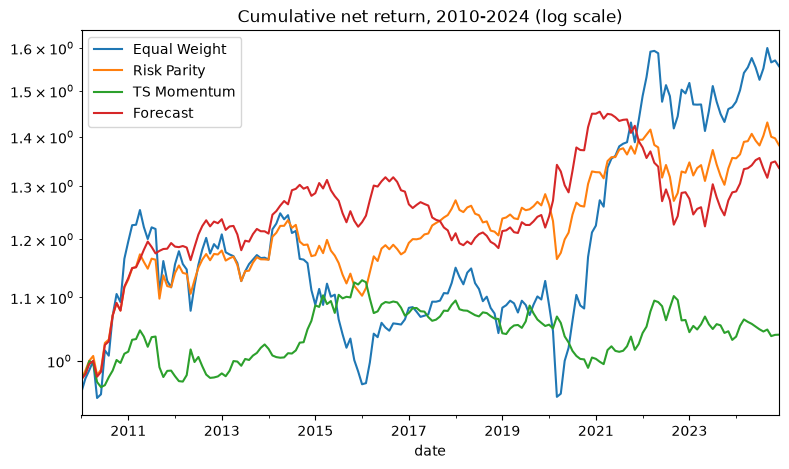

In [46]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, net in nets.items():
    (1 + net).cumprod().plot(ax=ax, label=name)
ax.set_yscale('log')
ax.legend(); ax.set_title('Cumulative net return, 2010-2024 (log scale)')
plt.show()


**Answer to question 3: no, not after costs.** The 2007–2009 validation picks the **random forest with macro** (validation MSE 1.539, against 1.576 for a no-predictor forecast). That is ironic, since the same model's out-of-sample $R^2$ is −0.030. Net of 10 bps per dollar traded, 2010–2024:

| portfolio | net Sharpe | gross Sharpe | ann. volatility | max drawdown | avg monthly turnover |
|---|---|---|---|---|---|
| Equal weight | 0.36 | 0.37 | 9.3% | −24.5% | 0.05 |
| Risk parity | **0.41** | 0.43 | 5.6% | −10.7% | 0.08 |
| TS momentum | 0.09 | 0.17 | 4.0% | −12.3% | 0.30 |
| Forecast (primary: random forest, chars + macro) | 0.39 | **0.48** | 5.3% | −15.8% | 0.41 |

**Before costs the forecast portfolio has the highest Sharpe ratio; after costs it does not beat risk parity.**
- **Turnover.** It trades five times as much as risk parity (0.41 of gross exposure a month against 0.08). It beats risk parity only below about 7 bps per dollar traded and trails it at 10, 20, 30 and 50 bps; above about 13 bps it also falls behind equal weight.
- **Exposure.** Underneath, it is largely risk parity: its net returns load 0.71 on risk parity (t = 4.6).
- **Alpha.** What the forecasts add on top is an annualized alpha of +1.0% with t = 0.78, not distinguishable from zero.
- **Timing of the record.** Its record is also concentrated in time: net Sharpe 1.05 in 2010–2014, −0.24 in 2015–2019 and 0.30 in 2020–2024, while risk parity is positive in all three blocks (0.54, 0.51, 0.26).

**None of these Sharpe differences is statistically significant.** In paired Jobson–Korkie–Memmel tests, forecast minus risk parity is −0.02 (p = 0.93), forecast minus equal weight +0.03 (p = 0.92), and even risk parity minus TS momentum, the widest benchmark gap, is +0.33 (p = 0.39). Over 15 years an annualized Sharpe ratio is estimated with a standard error of roughly $1/\sqrt{15}\approx 0.26$, so the benchmarks cannot be ranked reliably against each other either.

**The size of the search.** Under the same rule, the ten model × feature-set forecasts give net Sharpe ratios from 0.13 to 0.47. Four of the five characteristics-only versions cluster at 0.42–0.44, just above risk parity's 0.41 (the forest is 0.32). That is what the rule implies when forecasts are nearly constant: the portfolio is risk parity plus a small tilt (beta on risk parity 0.95–1.02), and the intercept-only forecast reproduces risk parity exactly (net Sharpe 0.4140). Against the three benchmarks, none of the ten has a significant alpha. The largest are +1.0% a year for the forest with macro (the primary, t = 0.78) and +0.9% for boosting with macro (t = 0.65; net Sharpe 0.47, the best of the ten). The characteristics-only alphas lie between −0.4% and +0.1% a year (|t| ≤ 1.1), and Ridge with macro is −1.2% (t = −1.4). Picking the best Sharpe ratio of ten after the fact would report a search result, not evidence.

**Diagnostics.**
- A purely cross-sectional version of the primary forecasts (demeaned $\hat y/\hat\sigma$, no common long tilt) earns a net Sharpe of only 0.07 (t = 0.29). Whatever the forecasts add is timing of the common exposure, not selection across assets.
- The original notebook's $\hat y\hat\sigma$ rule puts 73% of gross exposure in class A (risk parity: 26%) and earns 0.25.
- Risk parity has the best net Sharpe at every cost level from 10 to 50 bps. TS momentum is last at every level and turns negative from 20 bps.

**Exposure vs timing.** Risk parity's edge over equal weight comes from risk allocation, not timing. Inverse-volatility weighting moves gross weight out of class A (52% under equal weight, 26% under risk parity) into class D (14% → 38%) and class B (16% → 21%). These are the two low-volatility classes, and class D has the best Sharpe ratio in the panel. The forecast portfolios that edge past risk parity do so by holding risk parity plus a tilt, and the regressions show the tilt earns no significant alpha.

## What to submit

Two things, in this notebook:

1. **The analysis**, running top to bottom on the class server (or with `_DATA_DIR` pointed at a local copy of the data files), with every figure and table the write-up refers to.

2. **A write-up in the form of a research paper**, in markdown at the end of the notebook. The point of this project is to practise doing research, not to answer questions, so write it the way an empirical finance paper is written:

   - **Introduction.** The question, why it matters to someone who allocates money across countries and asset classes, what the literature on cross-sectional return predictability leads you to expect, and a one-paragraph preview of what you find.
   - **Data.** What the panel contains, how you treated it (missing values, lags, standardization, the country-to-asset mapping for macro), summary statistics and the plots that convey the structure of the data.
   - **Methodology.** The benchmarks and why they are the right ones; the models; the evaluation schemes and the out-of-sample window; how penalties and hyper-parameters were chosen; how forecasts become positions; how performance is measured. A reader should be able to reproduce your design from this section alone.
   - **Results.** Tables and figures with the numbers, presented in the order of the questions: forecastability of returns, the contribution of macro, and the portfolio evidence against the benchmarks.
   - **Interpretation and discussion.** What the results mean economically. Why the numbers come out the way they do; where the evidence is strong and where it is fragile; what you tried that did not work; what you would do next with more data or more time.
   - **Conclusion.** A summary a portfolio manager could read on their own.

   There is no length requirement in either direction. Length should follow from what you have to say; a clear negative result written up carefully is a good paper.


---
## Write-up

### Introduction

A desk that allocates across countries and asset classes wants to know three things. Do the asset-level characteristics that the empirical asset-pricing literature finds useful (momentum, value or long-term reversal, carry-type fundamentals, risk) forecast next month's excess return in a cross-country, cross-asset-class panel? Does macroeconomic information add anything on top? And can a portfolio built on the forecasts beat simple rules after costs? If the characteristics forecast returns, the desk can tilt away from naive allocations. If they do not, the useful answer is to say so and fall back on robust rules.

The literature (characteristic sorts in the Fama–French tradition, and machine-learning forecasts in the style of Gu, Kelly and Xiu) finds *some* out-of-sample predictability in liquid equity markets, but a small amount. Lecture 5 puts published monthly stock-level out-of-sample $R^2$ at about 0.3–0.5%. Nothing guarantees that even this survives pooling across asset classes whose volatilities differ by a factor of five.

**Preview.** On this panel, lagged characteristics carry no out-of-sample signal that we can distinguish from zero, or even from a forecast that uses no predictors at all. The best characteristics-only specification's $R^2_{OOS}$ against the trailing mean is −0.0001 (t = −0.03), and no model, scheme or feature set clears zero with any statistical support. Macro information does not help: it usually hurts, and correctly dated macro does no better than the same series moved 12–60 months in time. A portfolio built from the forecast chosen in advance on training data (a random forest with macro) has the best Sharpe ratio before costs. It trades five times as much as risk parity, though, and net of 10 bps it falls to 0.39, below risk parity's 0.41. It is mostly risk-parity exposure (beta 0.71), and its alpha of +1.0% a year has t = 0.78. This is a negative result, and the rest of the paper documents how we established it.

### Data

The panel has 50 assets in four classes (A: 26, B: 8, C: 9, D: 7) across 12 countries, monthly from January 2000 to December 2024. It carries five anonymized characteristics `x1`–`x5`, four global macro series `x6`–`x9`, seven curated country series `x10`–`x16`, and a 148-column extended country file `x17`–`x164`.

**Structure** (Section 1 tables and figures: per-asset statistics, cumulative returns by class, the correlation heatmap and rolling Sharpe ratios). Annualized volatility averages 30% in class A, 17% in C, 10% in B and 6% in D, and Sharpe ratios run from −0.03 (B) to 0.46 (D). Within-class return correlation is high in C (0.73), D (0.58) and B (0.55) and lowest in A (0.21). Class D is mildly negatively correlated with A and C. Year-to-year persistence in class Sharpe ratios is close to zero.

**What the characteristics are.** Comparing them with quantities built from each asset's own returns identifies three of the five:
- `x2` is the trailing 12-month compounded return, i.e. momentum (correlation 0.993);
- `x3` is minus the trailing 60-month return, i.e. long-term reversal or value (correlation −0.94);
- `x5` is trailing 36-month volatility, the risk measure (correlation 1.000).

`x1` and `x4` are unrelated to past returns and live on class-specific scales. `x1`'s cross-sectional standard deviation is 0.96 in class D and 0.001 in class B, and `x4`'s is 0.6 in B and C and 0.002 in D. They look like carry or valuation ratios computed from each class's own fundamentals.

**Treatment.**
- *Lags:* `x2`, `x5` are used as stored; `x1`, `x3`, `x4` and all macro are lagged one month within asset or country. The exception is `x10`, a calendar-year figure stamped on every month of its year, which is lagged 13 months so that it is used only after the year has ended.
- *Backfill:* the backfilled leading values of `x2`, `x3`, `x5` are detected as leading runs of identical values and blanked (`x3` for five assets, 30–31 months each; `x2` for two; `x5` for one).
- *`x11`:* it stops updating for `country_12` (after October 2020), `country_9` (August 2021) and `country_11` (March 2024), i.e. two of the three stop just before the 2021–23 inflation surge. It is rebuilt by chain-linking: the last observed value plus the subsequent change in the complete series `x86 − x12`, which correlates 0.988 with `x11` where both exist. In a 36-month pseudo-out-of-sample test this cuts the error of forward-filling by a factor of 7–19.
- *Extended file:* seven columns with trailing gaps are forward-filled, and eleven duplicates are dropped (exact copies of six curated and all four global series, plus one sign-flipped pair). The file is otherwise not used as features.
- *Country mapping:* each asset gets its own country's macro. Class A gets `country_7` by the files' convention, plus each curated variable's differential against `country_7`. The differentials are therefore identically zero for the 28 assets mapped to `country_7`.
- *Standardization:* characteristics are z-scored within month and within class; global macro gets a trailing 60-month z-score.

The final predictor table lists 23 predictors: 5 characteristics, 4 global, 7 country levels and 7 differentials.

### Methodology

**Target.** $y_{i,t} = r_{i,t}/\hat\sigma_{i,t-1}$, the excess return scaled by 12-month trailing volatility, so that one pooled squared-error loss treats a class-A and a class-D asset alike. Forecasts are converted back with $\hat r = \hat y\,\hat\sigma_{i,t-1}$.

**Benchmarks.** For returns: the trailing mean of all assets' excess returns through $t-1$, recomputed monthly and identical for every model, and zero. For classes we also use a class-level trailing mean. For portfolios: equal weight, risk parity ($1/\hat\sigma$) and time-series momentum ($\mathrm{sign}(\text{12-month return})/\hat\sigma$), all at unit gross exposure and rebalanced monthly.

**Evaluation.** The initial training block runs to December 2009 (from January 2001 for characteristics, January 2002 once macro is included). The out-of-sample window is January 2010–December 2024, fixed before any fitting. Models are refit each January on an expanding window or a 120-month rolling window. $R^2_{OOS} = 1 - \mathrm{SSE}_{model}/\mathrm{SSE}_{bench}$ (Lecture 4) on raw returns, as the exam asks, reported with a Newey–West t-statistic of the monthly loss difference. Class A supplies 88% of the benchmark's squared error, so we also report the same $R^2$ on the vol-scaled target, where every asset counts per unit of risk.

**Models and tuning.**
- OLS.
- Ridge and Lasso, standardized inside the pipeline, with the penalty re-chosen at every refit on the last 36 months of the training window (Lecture 5's recursive train / validate / test scheme; Lasso grid $2^{-10}$ to $2^{-1.3}$).
- Random forest: 200 trees, with depth and leaf size chosen once per feature set on 2007–2009 validation.
- Gradient boosting: depth 2, learning rate 0.05, with the number of rounds (≤ 300) re-chosen at every refit on the last 36 months of the training window, as for Ridge and Lasso (Lecture 8).
- Each model is run on characteristics only and on characteristics plus macro, under both schemes: 20 specifications.

**Checks.**
- A **placebo**: every macro series circularly shifted by 12, 24, 36, 48 and 60 *months* within country, over the same rows.
- Pooled vs **per-class** models, scored against the same benchmark.
- The same linear models with characteristics z-scored across all assets instead of within class.
- Global and country macro separately, on a common sample.
- A structured-noise control: 18 persistent noise columns in the same layout as the macro block.
- An intercept-only (no-predictor) reference, and Newey–West tests of every loss difference.
- Paired Sharpe-ratio tests between portfolios.

**Portfolios.** Weights $\propto \hat y/\hat\sigma$ (the vol-scaled forecast scaled by volatility; a constant forecast gives risk parity), unit gross. The primary forecast model is chosen before the out-of-sample period, as the lowest 2007–2009 validation MSE among the ten candidates, each fitted on data before 2007. This picks the random forest with macro. We also report all ten model × feature-set forecast portfolios, and each portfolio's alpha against the three benchmarks. Turnover is measured against drifted weights and charged 10 bps per dollar traded (sensitivity 0–50 bps).

### Results

$R^2_{OOS}$ against the trailing mean (Section 4):

| model | chars, expanding | chars, rolling | chars+macro, expanding | chars+macro, rolling |
|---|---|---|---|---|
| Intercept only (no predictors) | −0.0019 | −0.0023 | | |
| OLS | −0.0013 | −0.0049 | −0.0421 | −0.1353 |
| Ridge (tuned each refit) | −0.0010 | −0.0041 | −0.0245 | −0.0134 |
| Lasso (tuned each refit) | **−0.0001** | −0.0044 | −0.0130 | −0.0197 |
| Random forest (settings validated once) | −0.0065 | −0.0150 | −0.0304 | −0.0465 |
| Gradient boosting (tuned rounds) | −0.0031 | −0.0040 | −0.0033 | +0.0023 |

**Q1 — forecastability from characteristics.**
- **Range.** Characteristics-only $R^2_{OOS}$ against the trailing mean runs from −0.0150 to −0.0001 across the five models and two schemes. The best cells are the tuned Lasso (−0.0001, t = −0.03) and Ridge (−0.0010) under the expanding window; the Lasso is the best of the 10 characteristics-only cells, and of all 20 main cells only boosting with macro under the rolling window is higher (+0.0023, t = 0.29). Against zero the Lasso is +0.0006, also indistinguishable from nothing.
- **Against no predictors.** A forecast with no predictors scores −0.0019. On the vol-scaled target, the characteristics-only linear models and that forecast are all within ±0.0002 of zero.
- **Class A weight.** The raw-return $R^2$ is mostly a class-A statistic: class A supplies 88% of the benchmark's squared error.
- **Selection.** The only characteristic the Lasso keeps consistently is `x5` (low volatility → higher vol-scaled return), and even that fit is empty in three of fifteen years.
- **Nonlinearity.** Trees find none (forest −0.0065, boosting −0.0031).
- **Schemes.** The expanding window beats the rolling window in 8 of 10 model/feature pairs: with a signal this weak, more data beats recency.
- **Standardization.** Z-scoring across all assets instead of within class makes the characteristics-only models worse (OLS −0.0123, t = −2.3), as the class-specific scales of `x1` and `x4` predict.

**Q2 — the contribution of macro.**
- **Grid.** Adding macro lowers $R^2_{OOS}$ for OLS (−0.042 expanding, −0.135 rolling; t = −1.7 and −3.1), Ridge, Lasso and the forest. For boosting it is roughly neutral: −0.0033 against −0.0031 expanding, and +0.0023 (t = 0.29) under the rolling window, the only positive raw-return cell in the grid.
- **Global vs country.** On a common sample, global macro alone is roughly neutral. Country macro alone hurts OLS but, under the rolling window, gives Ridge +0.0068 and Lasso +0.0049 (t = 0.75, 0.50). These are the best 2 of 21 split cells. Both beat all their placebos, but pure noise of the same structure reaches +0.009: a hypothesis, not a result.
- **Noise control.** Eighteen persistent noise columns built exactly like the macro block score −0.052 to −0.021 for OLS and −0.017 to +0.009 for the Lasso. Real macro (−0.042, −0.013) is inside both ranges, indistinguishable from noise of the same structure.
- **Placebo.** It settles the question for the full macro block (Section 5):

  | model | no macro | real macro | best placebo | rank of real macro (of 6) |
  |---|---|---|---|---|
  | OLS | −0.0013 | −0.0421 | −0.0069 (60m) | 3 |
  | Ridge | −0.0010 | −0.0245 | +0.0018 (60m) | 6 |
  | Lasso | −0.0001 | −0.0130 | +0.0009 (60m) | 5 |
  | Boosting | −0.0031 | −0.0033 | +0.0010 (12m) | 2 |

  Correctly timed macro is not distinguishable from mistimed macro.
- **By class.** Class B's positive $R^2$ against the pooled mean (+0.02) is a benchmark artifact. It turns negative against a class trailing mean and against zero, and an intercept-only forecast shows the same pattern. Class C's positive numbers track its mean return jumping from −0.09% to +0.73% a month after 2010, not skill.
- **Pooling.** The pooled model beats per-class models overall (−0.0001 vs −0.0044 with characteristics only, −0.013 vs −0.025 with macro), but not in every class.

**Q3 — portfolios** (Section 7; cumulative returns plotted there):

| 2010–2024 | net Sharpe (10 bps) | gross Sharpe | turnover / month |
|---|---|---|---|
| Risk parity | **0.41** | 0.43 | 0.08 |
| Primary forecast (random forest, chars + macro) | 0.39 | **0.48** | 0.41 |
| Equal weight | 0.36 | 0.37 | 0.05 |
| TS momentum | 0.09 | 0.17 | 0.30 |

- **Costs.** The forecast portfolio wins before costs but trails risk parity at any cost above about 7 bps per dollar traded.
- **Alpha.** It loads 0.71 on risk parity (t = 4.6), and its alpha against the three benchmarks is +1.0% a year (t = 0.78).
- **Sub-periods.** Its net Sharpe is 1.05 in 2010–14, −0.24 in 2015–19 and 0.30 in 2020–24.
- **Cross-section.** Its demeaned (pure cross-sectional) version earns only 0.07.
- **Significance.** None of the pairwise Sharpe differences among the four portfolios is statistically significant (Jobson–Korkie–Memmel, p ≥ 0.39).
- **Search.** Across all ten model × feature-set forecast portfolios, net Sharpe ranges from 0.13 to 0.47. None earns a significant alpha against the three benchmarks (the largest is +1.0% a year, t = 0.78), and the characteristics-only portfolios are essentially risk parity (beta 0.95–1.02 on it).

Equal weight earns the most in raw terms (3.4% a year against 2.3% for risk parity), but with 1.7 times the volatility.

### Interpretation and discussion

The three answers are consistent. The characteristics carry no out-of-sample signal distinguishable from zero. Macro, which in a pooled monthly panel mostly moves the *level* of every forecast at once, behaves like noise with the same structure. Its damage matches that of 18 persistent random regressors, 11 of them shared by all assets. A portfolio built on those forecasts earns mostly what its common exposure (risk parity) earns. What it adds is statistically indistinguishable from zero and is eaten by trading costs. Economically, this panel rewards *risk allocation*: risk parity's edge over equal weight comes from moving weight from the 30%-volatility class A (52% of gross under equal weight, 26% under risk parity) to the low-volatility classes D and B. It does not reward *forecasting*.

**Where the evidence is strong.** The null is robust:
- across five model families, two schemes, four feature sets and two standardizations;
- against a benchmark fixed in advance, and against a forecast with no predictors;
- in a correctly implemented placebo, and against a structured-noise control.

Every penalty, boosting horizon, forest setting and the primary portfolio model was chosen on training data only. None of the portfolio Sharpe differences is statistically significant.

**Where it is fragile.** A few cells are slightly positive: boosting with macro under the rolling window, country macro alone in rolling Ridge/Lasso, the 60-month placebo for Ridge and Lasso, the 12-month placebo for boosting, and some class-level numbers. They are small, statistically indistinguishable from zero, and sensitive to the benchmark, the window or the shift. Portfolio results on these forecasts are especially fragile. The validation-chosen forest has the best validation score, and the best gross Sharpe of the four portfolios compared, but one of the worst out-of-sample $R^2$s. Among the ten forecast portfolios, net Sharpe ranges from 0.13 to 0.47 with no significant alpha.

Forecast-portfolio Sharpe ratios are therefore not a reliable measure of skill here; the alpha regressions are. The 99 rebuilt country-months of `x11` are estimates, although their pseudo-out-of-sample error is small (0.03–0.21 against a series standard deviation of 1.0–1.4). Two pockets survive the placebo test but not a significance test: class B (the only class where correctly dated macro beats every placebo for both OLS and the Lasso), and country macro alone in rolling Ridge/Lasso (within the range structured noise produces). Both were found by searching, with one window. They are hypotheses for a new sample, not results. The search was large: 20 main specifications plus an intercept-only reference, 7 robustness runs, 28 macro-split runs, 30 placebo runs, 10 noise-control runs and 4 per-class runs. A handful of positive draws is expected. We have one 15-year out-of-sample window and no independent second one. The forest's settings were tuned once on 2007–2009, not at every refit. Macro is lagged the minimum one month, which may be too little for some series. The 148 extended variables were not explored.

**What we tried and rejected.**
- z-scoring characteristics across all assets: worse, for the reasons in Section 1.
- The original notebook's portfolio rule $w\propto\hat y\hat\sigma$: it concentrates three quarters of the gross exposure in class A and mostly measures that tilt.
- Forward-filling `x11`: a much larger error than rebuilding it from `x86 − x12`.
- Per-class models: fewer rows, worse overall.
- Forest settings and the portfolio model chosen on the 2007–2009 validation block: the characteristics-only forest ended up worse than the intercept-only forecast out of sample, and the validation-chosen portfolio model (the macro forest) had one of the worst out-of-sample $R^2$s. The one crisis-period validation block did not carry over.

Earlier results in this notebook that were wrong and have been removed: a "placebo" that shifted rows rather than months; tercile sorts on contemporaneous characteristics that made `x1` and `x4` look predictive; and a one-month lag on the annual series `x10`, which handed forecasts the average of months not yet observed.

**Next steps with more time or data.** (i) An independent test window, or a block bootstrap of 2010–2024, above all for the two macro pockets. (ii) Conditional models: characteristic × regime interactions rather than macro levels. (iii) Hypothesis-driven use of the extended file, with release dates to set proper lags. (iv) A cost-aware position rule (a no-trade band) for any signal that did show promise.

### Conclusion

For a portfolio manager: on this 50-asset, four-class, 12-country panel, the five characteristics and the macro data do not forecast next month's excess returns out of sample in any way we can distinguish from chance. Macro in particular is no better than the same data placed at the wrong dates. A forecast portfolio chosen in advance looks best before costs, but it trades five times as much as risk parity and loses the edge at realistic costs, with an alpha indistinguishable from zero. The recommendation is risk parity. In 2010–2024 it had the best net Sharpe (0.41), the shallowest drawdown and low turnover, and was positive in each five-year block, although over 15 years no Sharpe difference between these rules is statistically significant. Any forecast-based tilt on these signals should be treated as unproven.
